In [9]:
import json
import os
import pickle
from math import ceil
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.formula.api import logit
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [10]:
# ------------------------------------------------------------------
# PATH
# ------------------------------------------------------------------
DATA_DIR = Path("../data/processed/preprocessed")
CV_DIR = DATA_DIR / "cv_folds"

# ------------------------------------------------------------------
# REPRESENTATIVE SPLITS
# ------------------------------------------------------------------
train_repr = pd.read_parquet(DATA_DIR / "train_repr.parquet")
val_repr   = pd.read_parquet(DATA_DIR / "val_repr.parquet")
test_out   = pd.read_parquet(DATA_DIR / "test.parquet")

# ------------------------------------------------------------------
# CV FOLDS
# ------------------------------------------------------------------
imputed_folds = []

fold_id = 1
while True:
    train_file = CV_DIR / f"fold_{fold_id}_train.parquet"
    val_file   = CV_DIR / f"fold_{fold_id}_val.parquet"

    if not train_file.exists():
        break

    tr = pd.read_parquet(train_file)
    vl = pd.read_parquet(val_file)

    imputed_folds.append((tr, vl))
    fold_id += 1

print(f"Loaded {len(imputed_folds)} CV folds")

print(f"train_repr : {train_repr.shape}")
print(f"val_repr   : {val_repr.shape}")
print(f"test_out   : {test_out.shape}")

Loaded 5 CV folds
train_repr : (43345, 63)
val_repr   : (5461, 63)
test_out   : (5261, 63)


## Biến đổi biến mục tiêu & Xử lý mất cân bằng dữ liệu (Target Variable Engineering & Imbalance)

* **Xác định độ tin cậy của nhãn (`target_reliable`):** Thiết lập cờ logic loại trừ các dòng dữ liệu MNAR (trạm mất thiết bị đo mưa hệ thống) hoặc chứa giá trị lấp đầy (sentinel values) để đảm bảo mô hình không học trên dữ liệu nhiễu.
* **Phân tích phân phối lượng mưa (`analyze_prcp_distribution`):** Thống kê số lượng ô trống, phân phối tỷ lệ ngày mưa/không mưa theo tiêu chuẩn WMO, tính toán các phân vị cốt lõi ($P_{50}$ đến $P_{99}$) trên dải giá trị dương và bóc tách tỷ lệ mưa cực đoan (>100mm) theo từng trạm.
* **Tự động lựa chọn cấu trúc phân lớp (`decide_n_class`):** Đánh giá tính khả thi (feasibility) của các kịch bản phân lớp (4-class, 3-class, nhị phân) dựa trên kích thước phân lớp tối thiểu (`MIN_CLASS_SIZE` = 500) và hệ số mất cân bằng dữ liệu ($IR \le 50$).
* **Ánh xạ biến mục tiêu chuyên biệt (`create_target`):** Tích hợp cấu trúc phân lớp tối ưu vào các thuộc tính mới gồm `rain_class` (nhãn đa lớp dạng `Int64` hỗ trợ giá trị rỗng) và `rain_binary` (ngưỡng mưa diện rộng $\ge$ 25mm).
* **Chẩn đoán mất cân bằng và dịch chuyển phân phối (`imbalance_diagnosis` & `covariate_shift_check`):** Theo dõi biến động tỷ lệ thiên tai theo từng tháng/trạm và đo lường mức độ dịch chuyển phân phối giữa các tập dữ liệu Train/Val/Test dựa trên ngưỡng cảnh báo thiết lập cố định (5%).
* **Tính toán trọng số phân lớp độc lập (`compute_weights`):** Áp dụng kỹ thuật cân bằng trọng số (`class_weight='balanced'`) biệt lập trên từng Fold huấn luyện và tập dữ liệu đại diện để triệt tiêu ảnh hưởng của hiện tượng mất cân bằng dữ liệu mà không làm rò rỉ thông tin thời gian.

In [11]:
# ═══════════════════════════════════════════════════════════════
# PHASE 7 — TARGET VARIABLE ENGINEERING & IMBALANCE
# ═══════════════════════════════════════════════════════════════
# Input  : fold_data (list of dicts), train_repr, val_repr, test
#          (đã qua imputation ở Phase 6)
# Output : Cùng objects với thêm cột:
#            - target_reliable (bool)
#            - rain_class      (Int64, có thể NA)
#            - rain_binary     (Int64, có thể NA)
#          + CLASS_WEIGHT dict fit trên train_repr
#          + class_weight per fold trong fold_data[i]['class_weight']
# ═══════════════════════════════════════════════════════════════

# ── Constants ──────────────────────────────────────────────────
STATION_COL = 'STATION'
DATE_COL    = 'DATE'

# WMO rainfall thresholds (mm)
WMO_TRACE    = 0.1
WMO_LIGHT    = 10.0
WMO_MODERATE = 25.0
WMO_HEAVY    = 50.0
WMO_EXTREME  = 100.0

MIN_CLASS_SIZE     = 500   # ngưỡng tối thiểu để giữ class riêng
COVARIATE_SHIFT_THR = 5.0  # % — cảnh báo nếu vượt


# ═══════════════════════════════════════════════════════════════
# BƯỚC 7.0 — DEFINE target_reliable
# ═══════════════════════════════════════════════════════════════
# Logic: dòng chỉ đáng tin nếu:
#   1. Trạm CÓ thiết bị đo mưa    → prcp_mnar_station == 0
#   2. Giá trị không phải sentinel → prcp_sentinel_original == False
#
# Nếu muốn thay đổi điều kiện, chỉnh hàm dưới đây.

def define_target_reliable(df: pd.DataFrame) -> pd.Series:
    """
    Trả về boolean Series: True = dòng đáng tin để dùng làm target.
    """
    cond_mnar = df['prcp_mnar_station'] == 0
    if 'prcp_sentinel_original' in df.columns:
        cond_sentinel = df['prcp_sentinel_original'] == False  # noqa: E712
        return cond_mnar & cond_sentinel
    return cond_mnar


# ═══════════════════════════════════════════════════════════════
# BƯỚC 7.1 — PHÂN PHỐI PRCP
# ═══════════════════════════════════════════════════════════════

def analyze_prcp_distribution(df: pd.DataFrame,
                               split_name: str = '') -> dict:
    sub  = df[df['target_reliable']].copy()
    prcp = sub['prcp_gsod_mm'].fillna(0)

    n_total   = len(prcp)
    n_no_rain = int((prcp < WMO_TRACE).sum())
    n_rain    = int((prcp >= WMO_TRACE).sum())
    pct_no    = n_no_rain / n_total * 100
    pct_rain  = n_rain    / n_total * 100

    # Percentiles trên phần dương
    pos  = prcp[prcp >= WMO_TRACE]
    pcts = {}
    if len(pos) > 0:
        pcts = {p: round(float(pos.quantile(p / 100)), 2)
                for p in [50, 75, 90, 95, 99]}

    bins = {
        'no_rain (<0.1mm)'       : int((prcp < WMO_TRACE).sum()),
        'light (0.1–10mm)'       : int(((prcp >= WMO_TRACE)    & (prcp < WMO_LIGHT)).sum()),
        'moderate (10–25mm)'     : int(((prcp >= WMO_LIGHT)    & (prcp < WMO_MODERATE)).sum()),
        'heavy (25–50mm)'        : int(((prcp >= WMO_MODERATE) & (prcp < WMO_HEAVY)).sum()),
        'very_heavy (50–100mm)'  : int(((prcp >= WMO_HEAVY)    & (prcp < WMO_EXTREME)).sum()),
        'extreme (>100mm)'       : int((prcp >= WMO_EXTREME).sum()),
    }

    print(f"\n[{split_name}] PRCP distribution  (target_reliable={n_total:,})")
    print(f"  No rain (<0.1 mm) : {n_no_rain:>6,}  ({pct_no:.1f}%)")
    print(f"  Rain   (≥0.1 mm)  : {n_rain:>6,}  ({pct_rain:.1f}%)")
    if pcts:
        print("  Percentiles (positive only):")
        for p, v in pcts.items():
            print(f"    P{p:>2} : {v:.2f} mm")
    print("  WMO bins:")
    for name, n in bins.items():
        pct = n / n_total * 100
        print(f"    {name:<28}  n={n:>5,}  ({pct:.2f}%)")

    # Extreme per station
    print("  Extreme (>100mm) rate per station:")
    station_extreme = (
        sub.assign(is_extreme=(prcp >= WMO_EXTREME))
        .groupby(STATION_COL)['is_extreme']
        .agg(n_extreme='sum',
             pct_extreme=lambda x: round(x.mean() * 100, 3))
        .sort_values('pct_extreme', ascending=False)
    )
    print(station_extreme.to_string())

    return {
        'n_total'    : n_total,
        'n_no_rain'  : n_no_rain,
        'n_rain'     : n_rain,
        'percentiles': pcts,
        'wmo_bins'   : bins,
    }


# ═══════════════════════════════════════════════════════════════
# BƯỚC 7.2 — QUYẾT ĐỊNH SỐ CLASS (tự động từ train distribution)
# ═══════════════════════════════════════════════════════════════

def decide_n_class(bins_train: dict, n_total: int) -> tuple[int, float]:
    """
    Trả về (n_class, imbalance_ratio) dựa trên data train.
    Ưu tiên scheme chi tiết nhất còn feasible.
    """
    def eval_scheme(counts: dict, label: str) -> tuple[bool, float]:
        min_n = min(counts.values())
        max_n = max(counts.values())
        ir    = round(max_n / min_n, 1) if min_n > 0 else float('inf')
        ok    = (min_n >= MIN_CLASS_SIZE) and (ir <= 50)
        print(f"  {label:12s}  IR={ir:6.1f}  min_class={min_n:,}"
              f"  {'✅ feasible' if ok else '❌ skip'}")
        for cls, n in counts.items():
            print(f"    {cls:<22}  n={n:>6,}  ({n/n_total*100:.2f}%)")
        return ok, ir

    c4 = {
        'no_rain'    : bins_train['no_rain (<0.1mm)'],
        'light+mod'  : bins_train['light (0.1–10mm)'] + bins_train['moderate (10–25mm)'],
        'heavy'      : bins_train['heavy (25–50mm)']  + bins_train['very_heavy (50–100mm)'],
        'extreme'    : bins_train['extreme (>100mm)'],
    }
    c3 = {
        'no_rain'    : bins_train['no_rain (<0.1mm)'],
        'normal'     : (bins_train['light (0.1–10mm)'] +
                        bins_train['moderate (10–25mm)'] +
                        bins_train['heavy (25–50mm)']),
        'extreme'    : bins_train['very_heavy (50–100mm)'] + bins_train['extreme (>100mm)'],
    }
    c2 = {
        'no_heavy'   : (bins_train['no_rain (<0.1mm)'] +
                        bins_train['light (0.1–10mm)'] +
                        bins_train['moderate (10–25mm)']),
        'heavy_plus' : (bins_train['heavy (25–50mm)'] +
                        bins_train['very_heavy (50–100mm)'] +
                        bins_train['extreme (>100mm)']),
    }

    print(f"\n  Đánh giá schemes (MIN_CLASS_SIZE={MIN_CLASS_SIZE:,}):")
    f4, ir4 = eval_scheme(c4, '4-class')
    f3, ir3 = eval_scheme(c3, '3-class')
    _,  ir2 = eval_scheme(c2, 'binary')

    if f4:
        return 4, ir4
    elif f3:
        return 3, ir3
    else:
        return 2, ir2


# ═══════════════════════════════════════════════════════════════
# BƯỚC 7.3 — TẠO TARGET COLUMNS
# ═══════════════════════════════════════════════════════════════

def assign_rain_class(prcp_series: pd.Series, n_class: int) -> pd.Series:
    """
    Map prcp (mm) → class label.  NaN passthrough.
    n_class=2 : 0=<25mm,  1=≥25mm
    n_class=3 : 0=<0.1mm, 1=0.1–50mm, 2=≥50mm
    n_class=4 : 0=<0.1mm, 1=0.1–25mm, 2=25–100mm, 3=≥100mm
    """
    if n_class == 2:
        cuts = [-np.inf, WMO_MODERATE, np.inf]
        labels = [0, 1]
    elif n_class == 3:
        cuts = [-np.inf, WMO_TRACE, WMO_HEAVY, np.inf]
        labels = [0, 1, 2]
    else:
        cuts = [-np.inf, WMO_TRACE, WMO_MODERATE, WMO_EXTREME, np.inf]
        labels = [0, 1, 2, 3]

    return pd.cut(prcp_series, bins=cuts, labels=labels).astype('Int64')


def create_target(df: pd.DataFrame,
                  n_class: int,
                  split_name: str = '') -> pd.DataFrame:
    """
    Thêm 3 cột vào df:
      target_reliable : bool
      rain_class      : Int64 (NA nếu không reliable)
      rain_binary     : Int64 (NA nếu không reliable), 1 = ≥25mm
    """
    df = df.copy()

    # 7.0 — define target_reliable nếu chưa có
    df['target_reliable'] = define_target_reliable(df)

    mask = df['target_reliable']
    prcp = df.loc[mask, 'prcp_gsod_mm'].fillna(0)

    # rain_class
    df['rain_class']  = pd.array([pd.NA] * len(df), dtype='Int64')
    df['rain_binary'] = pd.array([pd.NA] * len(df), dtype='Int64')

    df.loc[mask, 'rain_class']  = assign_rain_class(prcp, n_class).values
    df.loc[mask, 'rain_binary'] = (prcp >= WMO_MODERATE).astype(int).values

    # Distribution report
    dist = (
        df.loc[mask, 'rain_class']
        .value_counts(normalize=True)
        .sort_index()
        .mul(100).round(2)
    )
    n_rel = mask.sum()
    print(f"\n[{split_name}] rain_class  (n_reliable={n_rel:,}  "
          f"n_unreliable={len(df)-n_rel:,})")
    for cls, pct in dist.items():
        n = int((df.loc[mask, 'rain_class'] == cls).sum())
        print(f"  class {cls}: n={n:>6,}  ({pct:.2f}%)")

    return df


# ═══════════════════════════════════════════════════════════════
# BƯỚC 7.4 — IMBALANCE DIAGNOSIS
# ═══════════════════════════════════════════════════════════════

def imbalance_diagnosis(df: pd.DataFrame,
                        n_class: int,
                        split_name: str = '') -> dict:
    sub = df[df['target_reliable']].copy()
    sub['_month'] = pd.to_datetime(sub[DATE_COL]).dt.month

    counts = sub['rain_class'].value_counts().sort_index()
    ir     = round(counts.max() / counts.min(), 1)

    print(f"\n[{split_name}] Imbalance Ratio = {ir}")
    print(counts.to_string())

    extreme_cls = n_class - 1

    print(f"\n  Extreme (class {extreme_cls}) rate per station:")
    st = (
        sub.groupby(STATION_COL)['rain_class']
        .apply(lambda x: round((x == extreme_cls).mean() * 100, 2))
        .sort_values(ascending=False)
        .rename('pct_extreme')
    )
    print(st.to_string())

    print(f"\n  Extreme (class {extreme_cls}) rate per month:")
    mo = (
        sub.groupby('_month')['rain_class']
        .apply(lambda x: round((x == extreme_cls).mean() * 100, 2))
        .rename('pct_extreme')
    )
    print(mo.to_string())

    return {'ir': ir, 'counts': counts.to_dict()}


# ═══════════════════════════════════════════════════════════════
# BƯỚC 7.5 — CLASS WEIGHT
# ═══════════════════════════════════════════════════════════════

def compute_weights(df: pd.DataFrame,
                    split_name: str = '') -> dict:
    y = (
        df.loc[df['target_reliable'], 'rain_class']
        .dropna().astype(int).values
    )
    classes = np.unique(y)
    weights = compute_class_weight(class_weight='balanced',
                                   classes=classes, y=y)
    cw = dict(zip(classes.tolist(), weights.tolist()))

    print(f"\n[{split_name}] class_weight (balanced):")
    for cls, w in cw.items():
        n = int((y == cls).sum())
        print(f"  class {cls}: weight={w:.4f}  (n={n:,})")

    return cw


# ═══════════════════════════════════════════════════════════════
# BƯỚC 7.6 — COVARIATE SHIFT CHECK
# ═══════════════════════════════════════════════════════════════

def covariate_shift_check(splits: dict[str, pd.DataFrame],
                           n_class: int) -> None:
    print("\n  Covariate shift check (rain_class %):")
    for cls in range(n_class):
        row = []
        for name, df in splits.items():
            sub = df[df['target_reliable']]
            pct = (sub['rain_class'] == cls).sum() / len(sub) * 100
            row.append((name, round(pct, 2)))

        vals = [v for _, v in row]
        flag = ''
        if max(vals) - min(vals) > COVARIATE_SHIFT_THR:
            flag = '  ⚠️  shift >{:.0f}%'.format(COVARIATE_SHIFT_THR)

        parts = '  '.join(f"{n}={v:.1f}%" for n, v in row)
        print(f"  class {cls}: {parts}{flag}")


# ═══════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ═══════════════════════════════════════════════════════════════

def run_phase7(train_repr: pd.DataFrame,
               val_repr:   pd.DataFrame,
               test:       pd.DataFrame,
               imputed_folds:  list[dict]) -> tuple[pd.DataFrame,
                                                pd.DataFrame,
                                                pd.DataFrame,
                                                list[dict],
                                                dict,
                                                int]:
    """
    Chạy toàn bộ Phase 7.

    Returns
    -------
    train_repr, val_repr, test  : DataFrames với target columns
    fold_data                   : list dicts, mỗi dict thêm key 'class_weight'
    CLASS_WEIGHT                : dict fit trên train_repr
    N_CLASS                     : int (2/3/4)
    """

    sep = "=" * 65

    # ── 7.1 PRCP distribution ─────────────────────────────────
    print(f"\n{sep}")
    print("BƯỚC 7.1 — PRCP DISTRIBUTION")
    print(sep)

    # Cần target_reliable để analyze — tạm thời define trên từng df
    for df in [train_repr, val_repr, test]:
        df['target_reliable'] = define_target_reliable(df)

    prcp_stats = {}
    for name, df in [('TRAIN', train_repr),
                     ('VAL',   val_repr),
                     ('TEST',  test)]:
        prcp_stats[name] = analyze_prcp_distribution(df, name)

    # ── 7.2 Decide N_CLASS ────────────────────────────────────
    print(f"\n{sep}")
    print("BƯỚC 7.2 — QUYẾT ĐỊNH SỐ CLASS")
    print(sep)

    N_CLASS, IR_TRAIN = decide_n_class(
        prcp_stats['TRAIN']['wmo_bins'],
        prcp_stats['TRAIN']['n_total']
    )
    print(f"\n  → Chọn: {N_CLASS}-class  (IR train = {IR_TRAIN})")

    # ── 7.3 Create targets ────────────────────────────────────
    print(f"\n{sep}")
    print(f"BƯỚC 7.3 — TẠO TARGET  (n_class={N_CLASS})")
    print(sep)

    train_repr = create_target(train_repr, N_CLASS, 'TRAIN')
    val_repr   = create_target(val_repr,   N_CLASS, 'VAL')
    test       = create_target(test,       N_CLASS, 'TEST')

    # ── 7.4 Imbalance diagnosis ───────────────────────────────
    print(f"\n{sep}")
    print("BƯỚC 7.4 — IMBALANCE DIAGNOSIS")
    print(sep)

    imbalance_diagnosis(train_repr, N_CLASS, 'TRAIN')

    # ── 7.5 Class weight (representative) ────────────────────
    print(f"\n{sep}")
    print("BƯỚC 7.5 — CLASS WEIGHT (train_repr 2015–2022)")
    print(sep)

    CLASS_WEIGHT = compute_weights(train_repr, 'TRAIN')
    print(f"\n  ✅ CLASS_WEIGHT = {CLASS_WEIGHT}")

    # ── 7.6 Covariate shift ───────────────────────────────────
    print(f"\n{sep}")
    print("BƯỚC 7.6 — COVARIATE SHIFT CHECK")
    print(sep)

    covariate_shift_check(
        {'TRAIN': train_repr, 'VAL': val_repr, 'TEST': test},
        N_CLASS
    )

    # ── CV FOLDS ──────────────────────────────────────────────
    print(f"\n{sep}")
    print("APPLY TARGET → CV FOLDS")
    print(sep)

    # MỚI — đúng structure tuple
    new_folds = []
    fold_class_weights = {}
    
    for i, (tr, vl) in enumerate(imputed_folds, start=1):
        tr = create_target(tr, N_CLASS, f'FOLD{i}_TRAIN')
        vl = create_target(vl, N_CLASS, f'FOLD{i}_VAL')
        cw = compute_weights(tr, f'FOLD{i}')
        fold_class_weights[i] = cw
        new_folds.append((tr, vl))
        print(f"  Fold {i}: class_weight={cw}")

    # ── Summary ───────────────────────────────────────────────
    print(f"\n{sep}")
    print("✅ PHASE 7 HOÀN THÀNH")
    print(sep)
    print(f"  Target     : {N_CLASS}-class rain classification")
    print(f"  IR (train) : {IR_TRAIN}")
    print(f"  CLASS_WEIGHT: {CLASS_WEIGHT}")
    n_folds = len(new_folds)
    print(f"  Folds processed : {n_folds}")

    new_cols = ['target_reliable', 'rain_class', 'rain_binary']
    print(f"\n  New columns added to every split:")
    for c in new_cols:
        print(f"    - {c}")

    return train_repr, val_repr, test, new_folds, CLASS_WEIGHT, N_CLASS


train_repr, val_repr, test_out, new_folds, CLASS_WEIGHT, N_CLASS = run_phase7(
    train_repr, val_repr, test_out, imputed_folds
)


BƯỚC 7.1 — PRCP DISTRIBUTION

[TRAIN] PRCP distribution  (target_reliable=37,513)
  No rain (<0.1 mm) : 23,033  (61.4%)
  Rain   (≥0.1 mm)  : 14,480  (38.6%)
  Percentiles (positive only):
    P50 : 5.08 mm
    P75 : 17.53 mm
    P90 : 40.89 mm
    P95 : 61.98 mm
    P99 : 137.72 mm
  WMO bins:
    no_rain (<0.1mm)              n=23,033  (61.40%)
    light (0.1–10mm)              n=9,190  (24.50%)
    moderate (10–25mm)            n=2,678  (7.14%)
    heavy (25–50mm)               n=1,561  (4.16%)
    very_heavy (50–100mm)         n=  775  (2.07%)
    extreme (>100mm)              n=  276  (0.74%)
  Extreme (>100mm) rate per station:
             n_extreme  pct_extreme
STATION                            
48852099999         59        2.021
48863099999         43        1.489
48845099999         37        1.280
48848099999         30        1.038
48870099999         26        0.900
48831099999         14        0.498
48840099999         14        0.484
48826099999         13        0.4

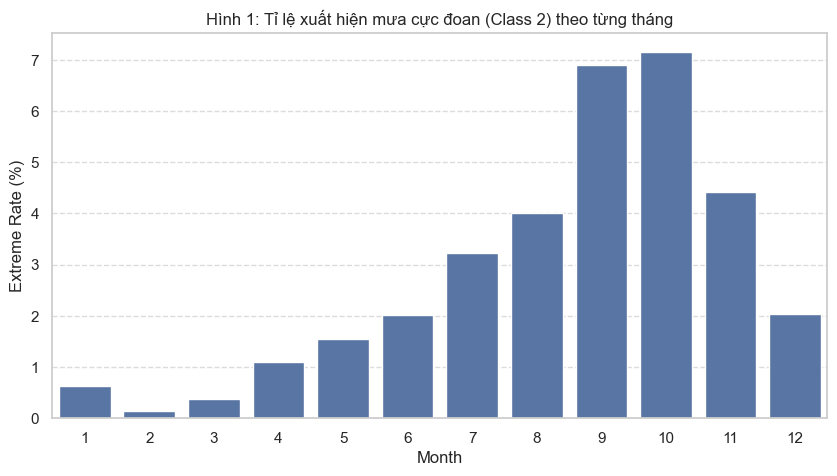

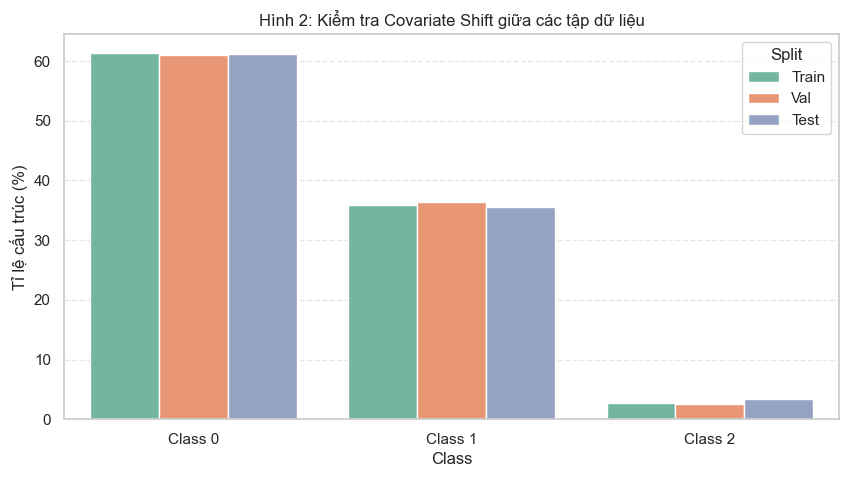

In [12]:

# 1. Vẽ biến động theo tháng (Insight 1)
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
rates = [0.63, 0.14, 0.38, 1.10, 1.55, 2.01, 3.23, 4.01, 6.90, 7.16, 4.42, 2.04]
df_month = pd.DataFrame({'Month': months, 'Extreme Rate (%)': rates})

plt.figure(figsize=(10, 5))
sns.barplot(data=df_month, x='Month', y='Extreme Rate (%)')
plt.title('Hình 1: Tỉ lệ xuất hiện mưa cực đoan (Class 2) theo từng tháng')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Vẽ so sánh 3 tập (Insight 3)
data_shift = {
    'Split': ['Train', 'Val', 'Test'] * 3,
    'Class': ['Class 0']*3 + ['Class 1']*3 + ['Class 2']*3,
    'Percentage (%)': [61.4, 61.0, 61.1, 35.8, 36.4, 35.5, 2.8, 2.6, 3.4]
}
df_shift = pd.DataFrame(data_shift)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_shift, x='Class', y='Percentage (%)', hue='Split', palette='Set2')
plt.title('Hình 2: Kiểm tra Covariate Shift giữa các tập dữ liệu')
plt.ylabel('Tỉ lệ cấu trúc (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## FEATURE ENGINEERING

In [13]:
# ═══════════════════════════════════════════════════════════════
# PHASE 8 — FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════
# Input  (từ Phase 7):
#   train_repr   : DataFrame 2015–2022  (đã có target cols)
#   val_repr     : DataFrame 2023
#   test_out     : DataFrame 2024
#   new_folds    : list of tuples (tr, vl), index 0 = fold 1
#                  mỗi tr/vl đã có rain_class, rain_binary
#   CLASS_WEIGHT : dict
#   N_CLASS      : int
#
# Output (cuối phase):
#   train_fe, val_fe, test_fe  : DataFrames đầy đủ rows, giữ prcp_gsod_mm — dùng cho EDA
#   new_folds_fe               : list tuples (tr_fe, vl_fe) — chuẩn để chạy model
#                                (đã drop prcp_gsod_mm, drop lag NaN rows đầu)
# ═══════════════════════════════════════════════════════════════

try:
    import requests
    _ENSO_AVAILABLE = True
except ImportError:
    _ENSO_AVAILABLE = False

# Target cols — không bao giờ dùng làm feature input
TARGET_COLS = ['rain_class', 'rain_binary', 'target_reliable']
# Cols dùng để join/index — không drop, không dùng làm feature
META_COLS   = ['STATION', 'DATE']

FEATURE_REGISTRY: dict = {}

# Encoding cố định cho enso_phase — dùng cả Phase 8 lẫn inference
_ENSO_PHASE_ENC = {'la_nina': 0, 'neutral': 1, 'el_nino': 2}


def _reg(col, method, uses_target=False):
    FEATURE_REGISTRY[col] = {'method': method, 'uses_target': uses_target}


# ═══════════════════════════════════════════════════════════════
# BƯỚC 8.0 — VALIDATE & TIME GRID FILLING
# ═══════════════════════════════════════════════════════════════

def fill_missing_dates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Đảm bảo mỗi trạm có continuous daily index từ min đến max date.
    Các ngày bị missing → insert row với NaN (trừ STATION, DATE).
    Bắt buộc trước khi tính lag/rolling để tránh positional shift sai.

    NOTE: gap rows được insert với NaN — target_reliable=NaN nên
    không lọt vào training targets. Với fold path, gap rows tự bị
    loại khi filter bằng (STATION, DATE) keys từ fold gốc.
    """
    df = df.copy()
    df['DATE'] = pd.to_datetime(df['DATE'])

    parts = []
    for station_id, grp in df.groupby('STATION', sort=False):
        grp = grp.sort_values('DATE')
        full_range = pd.date_range(grp['DATE'].min(), grp['DATE'].max(), freq='D')
        grp_filled = (grp
                      .set_index('DATE')
                      .reindex(full_range)
                      .rename_axis('DATE')
                      .reset_index())
        grp_filled['STATION'] = station_id
        parts.append(grp_filled)

    out = pd.concat(parts, ignore_index=True)
    n_inserted = len(out) - len(df)
    if n_inserted > 0:
        print(f"   fill_missing_dates: +{n_inserted:,} gap rows inserted")
    return out


def validate_df(df: pd.DataFrame, name: str = '') -> None:
    assert df[['STATION', 'DATE']].duplicated().sum() == 0, \
        f"[{name}] Duplicate (STATION, DATE) found."
    sorted_check = (
        df.sort_values(['STATION', 'DATE'])[['STATION', 'DATE']]
        .reset_index(drop=True)
        .equals(df[['STATION', 'DATE']].reset_index(drop=True))
    )
    assert sorted_check, f"[{name}] Must be sorted by (STATION, DATE)."
    print(f"   ✓ validate_df [{name}] passed  ({len(df):,} rows)")


def sort_df(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values(['STATION', 'DATE']).reset_index(drop=True)


# ═══════════════════════════════════════════════════════════════
# BƯỚC 8.1 — TEMPORAL FEATURES
# ═══════════════════════════════════════════════════════════════

STATION_REGION = {
    48820: 'bac',   48818: 'bac',
    48848: 'trung', 48852: 'trung', 48863: 'trung',
    48900: 'nam',   48914: 'nam',   48940: 'nam',   48915: 'nam',
    48826: 'bac',   48823: 'bac',   48831: 'trung',
    48840: 'trung', 48845: 'trung', 48866: 'nam',
    48870: 'nam',   48894: 'nam',   48907: 'nam',
}

def _get_region(station_id: int) -> str:
    sid = int(str(int(station_id))[:5])
    return STATION_REGION.get(sid, 'nam')

def _is_monsoon(month, region: str) -> int:
    if pd.isna(month): return 0
    if region == 'bac':   return int(5 <= month <= 10)
    if region == 'trung': return int(9 <= month <= 12)
    return int(5 <= month <= 11)

def _season_label(month, region: str) -> str:
    if pd.isna(month): return f"mua_unknown_{region}"
    return f"mua_{'mua' if _is_monsoon(month, region) else 'kho'}_{region}"

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt = df['DATE']

    df['year']         = dt.dt.year
    df['month']        = dt.dt.month
    df['day_of_year']  = dt.dt.dayofyear
    df['day_of_month'] = dt.dt.day
    # int (bukan Int64) — DATE luôn valid sau fill_missing_dates
    df['week_of_year'] = dt.dt.isocalendar().week.astype(int)
    for c in ['year','month','day_of_year','day_of_month','week_of_year']:
        _reg(c, 'temporal_basic')

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['doy_cos']   = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
    for c in ['month_sin','month_cos','doy_sin','doy_cos']:
        _reg(c, 'circular_encoding')

    regions = df['STATION'].apply(_get_region)
    df['is_monsoon']   = [_is_monsoon(m, r) for m, r in zip(df['month'], regions)]
    df['season_label'] = [_season_label(m, r) for m, r in zip(df['month'], regions)]
    _reg('is_monsoon',   'climate_season')
    _reg('season_label', 'climate_season')

    return df


# ═══════════════════════════════════════════════════════════════
# BƯỚC 8.1.4 — ENSO
# ═══════════════════════════════════════════════════════════════

_ENSO_CACHE: pd.DataFrame | None = None

def _fetch_enso_mei() -> pd.DataFrame | None:
    global _ENSO_CACHE
    if _ENSO_CACHE is not None:
        return _ENSO_CACHE
    url = 'https://psl.noaa.gov/enso/mei/data/meiv2.data'
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        rows = []
        for line in resp.text.splitlines():
            parts = line.strip().split()
            if len(parts) == 13 and parts[0].isdigit():
                yr = int(parts[0])
                for m, v in enumerate(parts[1:], 1):
                    try:
                        rows.append({'year': yr, 'month': m, 'mei_value': float(v)})
                    except ValueError:
                        pass
        enso_raw = pd.DataFrame(rows)
        enso_raw = enso_raw[enso_raw['mei_value'] > -99]

        # FIX: reindex complete month grid trước khi shift để tránh
        # positional error nếu ENSO data có gaps (filtered rows)
        yr_min, yr_max = int(enso_raw['year'].min()), int(enso_raw['year'].max())
        month_grid = pd.DataFrame([
            {'year': y, 'month': m}
            for y in range(yr_min, yr_max + 1)
            for m in range(1, 13)
        ])
        enso_complete = month_grid.merge(enso_raw, on=['year','month'], how='left')
        enso_complete = enso_complete.sort_values(['year','month']).reset_index(drop=True)

        # shift(3) trên complete grid → lag 3 tháng đúng calendar
        enso_complete['enso_mei_current'] = enso_complete['mei_value']
        enso_complete['enso_mei_3m_lag']  = enso_complete['mei_value'].shift(3)

        _ENSO_CACHE = enso_complete[['year','month','enso_mei_current','enso_mei_3m_lag']]
        print(f"   ✓ ENSO MEI loaded: {yr_min}–{yr_max}")
        return _ENSO_CACHE
    except Exception as e:
        print(f"   ⚠ ENSO fetch failed ({e}), skipping.")
        return None

def add_enso_features(df: pd.DataFrame) -> pd.DataFrame:
    enso = _fetch_enso_mei()
    if enso is None:
        return df
    df = df.copy()

    df = df.merge(enso[['year','month','enso_mei_current','enso_mei_3m_lag']],
                  on=['year','month'], how='left')

    df['enso_phase'] = 'neutral'
    df.loc[df['enso_mei_current'] >  0.5, 'enso_phase'] = 'el_nino'
    df.loc[df['enso_mei_current'] < -0.5, 'enso_phase'] = 'la_nina'

    # Encode ngay trong Phase 8 — giữ cả string lẫn int
    df['enso_phase_enc'] = df['enso_phase'].map(_ENSO_PHASE_ENC).astype('Int64')

    for c in ['enso_mei_current','enso_mei_3m_lag','enso_phase','enso_phase_enc']:
        _reg(c, 'enso')
    return df


# ═══════════════════════════════════════════════════════════════
# BƯỚC 8.2 — LAG FEATURES
# ═══════════════════════════════════════════════════════════════

LAG_CONFIG = {
    'prcp_gsod_mm'              : [1, 2, 3, 7],
    'precipitation_sum'         : [1, 3, 7],
    'cape_mean'                 : [1, 3],
    'relative_humidity_2m_mean' : [1, 3],
    'dew_point_2m_mean'         : [1],
    'pressure_msl_mean'         : [1],
    'cloud_cover_mean'          : [1],
    'temperature_2m_mean'       : [1],
    'temperature_2m_min'        : [1],
}

MAX_LAG_K = max(max(v) for v in LAG_CONFIG.values())  # = 7

def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    grp = df.groupby('STATION', sort=False)
    for col, lags in LAG_CONFIG.items():
        if col not in df.columns:
            continue
        for k in lags:
            nc = f'{col}_lag{k}'
            df[nc] = grp[col].shift(k)
            _reg(nc, f'lag_{k}', uses_target=(col == 'prcp_gsod_mm'))
    return df


# ═══════════════════════════════════════════════════════════════
# BƯỚC 8.3 — ROLLING FEATURES
# ═══════════════════════════════════════════════════════════════

def _rolling_shift(series: pd.Series, window: int, agg: str,
                   min_frac: float = 0.7) -> pd.Series:
    """
    Rolling window [t-w, t-1] — không dùng T.
    trailing roll(w) → shift(1) đảm bảo window = [t-w, t-1].
    min_periods = ceil(w * min_frac) để tránh NaN quá nhiều ở đầu chuỗi.
    """
    min_p = max(1, ceil(window * min_frac))
    rolled = series.rolling(window=window, min_periods=min_p)
    return getattr(rolled, agg)().shift(1)

ROLLING_CONFIG = [
    ('prcp_gsod_mm',                [3, 7, 14, 30], 'sum'),
    ('precipitation_sum',           [3, 7, 14],     'sum'),
    ('rain_sum',                    [7],             'sum'),
    ('showers_sum',                 [7],             'sum'),
    ('cape_mean',                   [3, 7],          'mean'),
    ('relative_humidity_2m_mean',   [3, 7],          'mean'),
    ('cloud_cover_mean',            [3, 7],          'mean'),
    ('soil_moisture_0_to_7cm_mean', [7],             'mean'),
    ('cape_max',                    [3],             'max'),
    ('wind_gusts_10m_max',          [3],             'max'),
    ('temperature_2m_mean',         [7],             'std'),
    ('pressure_msl_mean',           [7],             'std'),
]

MAX_ROLL_W = max(w for _, ws, _ in ROLLING_CONFIG for w in ws)  # = 30

def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    grp = df.groupby('STATION', sort=False)
    for col, windows, agg in ROLLING_CONFIG:
        if col not in df.columns:
            continue
        for w in windows:
            nc = f'{col}_roll{w}_{agg}'
            df[nc] = grp[col].transform(
                lambda s, _w=w, _a=agg: _rolling_shift(s, _w, _a)
            )
            _reg(nc, f'rolling_{agg}_{w}', uses_target=(col == 'prcp_gsod_mm'))
    return df


# ═══════════════════════════════════════════════════════════════
# BƯỚC 8.4 — THERMODYNAMIC FEATURES
# ═══════════════════════════════════════════════════════════════

def add_thermodynamic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if 'cape_mean' in df.columns:
        df['cape_log'] = np.log1p(df['cape_mean'])
        _reg('cape_log', 'cape_transform')

        bins   = [-np.inf, 100, 500, 1500, 3000, np.inf]
        labels = [0, 1, 2, 3, 4]
        df['cape_instability_index'] = pd.cut(
            df['cape_mean'], bins=bins, labels=labels
        ).astype(float)
        _reg('cape_instability_index', 'cape_bin')

    if 'cape_max' in df.columns:
        df['cape_max_log'] = np.log1p(df['cape_max'])
        _reg('cape_max_log', 'cape_transform')

    t_mean = 'temperature_2m_mean'
    wb     = 'wet_bulb_temperature_2m_mean'
    if t_mean in df.columns and wb in df.columns:
        df['wet_bulb_depression'] = df[t_mean] - df[wb]
        _reg('wet_bulb_depression', 'thermodynamic')

        df['pseudo_li'] = df[t_mean] - df[wb] - df.get('cape_mean', 0) / 300
        _reg('pseudo_li', 'thermodynamic')

    rh = 'relative_humidity_2m_mean'
    if 'cape_mean' in df.columns and rh in df.columns:
        df['cape_rh_interaction'] = df['cape_mean'] * df[rh] / 100
        _reg('cape_rh_interaction', 'interaction')

    dp_max = 'dew_point_2m_max'
    t_min  = 'temperature_2m_min'
    if dp_max in df.columns and t_min in df.columns:
        df['saturation_deficit_proxy'] = df[dp_max] - df[t_min]
        _reg('saturation_deficit_proxy', 'thermodynamic')

    return df


# ═══════════════════════════════════════════════════════════════
# BƯỚC 8.5 — ACF DIAGNOSTICS (informational)
# ═══════════════════════════════════════════════════════════════

def run_acf_diagnostics(train_df: pd.DataFrame,
                        target_col: str = 'prcp_gsod_mm',
                        max_lag: int = 30) -> dict:
    results = {}
    n_conf  = 1.96
    for station, grp in train_df.groupby('STATION'):
        series = grp.sort_values('DATE')[target_col].dropna()
        n = len(series)
        if n < max_lag + 10:
            continue
        conf = n_conf / np.sqrt(n)
        s    = series.values - series.mean()
        var  = np.var(s)
        if var == 0:
            continue
        acf = [np.mean(s[k:] * s[:-k]) / var for k in range(1, max_lag + 1)]
        sig = [k + 1 for k, v in enumerate(acf) if abs(v) > conf]
        results[station] = {'n': n, 'conf_bound': round(conf, 4),
                            'significant_lags': sig}

    print('\n   ACF significant lags per station:')
    for st, info in results.items():
        print(f"    {st}: {info['significant_lags'][:10]}  (n={info['n']})")
    return results


# ═══════════════════════════════════════════════════════════════
# BƯỚC 8.6 — LEAKAGE AUDIT
# ═══════════════════════════════════════════════════════════════

def leakage_audit(df: pd.DataFrame) -> pd.DataFrame:
    """
    Audit trên representative splits (train_fe) — prcp_gsod_mm còn tồn tại ở đây.
    Fold path đã drop prcp_gsod_mm riêng trong _prepare_fold_df().
    """
    skip = set(TARGET_COLS + META_COLS)
    report = []
    for col in df.columns:
        if col in skip:
            continue
        risk, reason = 'OK', ''
        if col == 'prcp_gsod_mm':
            risk   = 'HIGH'
            reason = 'Raw same-day prcp — PHẢI drop trước khi build feature matrix ở Phase 9'
        elif 'prcp_gsod_mm_roll' in col:
            risk   = 'REVIEW'
            reason = 'roll+shift(1) expected — verify _rolling_shift'
        report.append({'feature': col, 'risk': risk, 'reason': reason})

    audit_df = pd.DataFrame(report)
    high = audit_df[audit_df['risk'] == 'HIGH']
    rev  = audit_df[audit_df['risk'] == 'REVIEW']
    if len(high):
        print(f'\n   ⚠ LEAKAGE AUDIT: {len(high)} HIGH-RISK (phải xử lý ở Phase 9):')
        print(high.to_string(index=False))
    else:
        print(f'\n   ✓ LEAKAGE AUDIT: no HIGH-RISK features.')
    if len(rev):
        print(f'   ℹ {len(rev)} REVIEW features (roll+shift — expected).')
    return audit_df


# ═══════════════════════════════════════════════════════════════
# CORE TRANSFORM (stateless — không fit gì)
# ═══════════════════════════════════════════════════════════════

def _apply_all_transforms(df: pd.DataFrame,
                          split_name: str,
                          run_enso: bool) -> pd.DataFrame:
    """Áp dụng toàn bộ FE steps. df phải đã fill_missing_dates + sorted."""
    print(f'   [{split_name}] {len(df):,} rows → ', end='')
    df = add_temporal_features(df)
    if run_enso and _ENSO_AVAILABLE:
        df = add_enso_features(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_thermodynamic_features(df)
    print(f'{len(df.columns)} cols')
    return df


def _drop_initial_lag_rows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop MAX_LAG_K dòng đầu của mỗi trạm (không đủ lag history).
    Dùng DATE rank để tránh phụ thuộc integer index.
    """
    df = df.copy()
    df['_rr'] = df.groupby('STATION')['DATE'].rank(method='first')
    df = df[df['_rr'] > MAX_LAG_K].drop(columns='_rr')
    return df.reset_index(drop=True)


def _prepare_fold_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Chuẩn bị DataFrame cho model training/validation:
      - Drop prcp_gsod_mm (raw same-day target leak)
      - Drop enso_phase string (đã có enso_phase_enc)
      - Drop season_label string (đã one-hot ở Phase 7 hoặc handle ở Phase 9)
    Chỉ áp dụng cho fold path, KHÔNG áp dụng cho representative splits.
    """
    drop_cols = [c for c in ['prcp_gsod_mm', 'enso_phase', 'season_label']
                 if c in df.columns]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    return df


# ═══════════════════════════════════════════════════════════════
# PIPELINE CLASS
# ═══════════════════════════════════════════════════════════════

class FeatureEngineeringPipeline:
    """
    fit(train_repr)   : fill dates + ACF diagnostics (informational)
    transform(df)     : fill dates + apply all FE steps, no fitting

    Representative splits (train_fe/val_fe/test_fe):
        - Giữ đủ rows (kể cả gap rows từ fill)
        - Giữ prcp_gsod_mm, enso_phase, season_label
        - Dùng cho EDA / analysis

    Fold path (new_folds_fe):
        - Gap rows tự bị loại khi filter bằng (STATION, DATE) keys
        - Drop MAX_LAG_K rows đầu mỗi trạm
        - Drop prcp_gsod_mm + string cols qua _prepare_fold_df()
        - Chuẩn để chạy model
    """

    def __init__(self, run_enso: bool = True, run_acf: bool = True):
        self.run_enso     = run_enso
        self.run_acf      = run_acf
        self.acf_results_ = None
        self.fitted_      = False

    def fit(self, train_df: pd.DataFrame) -> 'FeatureEngineeringPipeline':
        train_filled = fill_missing_dates(sort_df(train_df))
        validate_df(train_filled, 'train_repr')
        if self.run_acf:
            print('\n[8.5] ACF diagnostics on train_repr...')
            self.acf_results_ = run_acf_diagnostics(train_filled)
        self.fitted_ = True
        print('\n   ✓ FeatureEngineeringPipeline fitted.')
        return self

    def transform(self, df: pd.DataFrame,
                  split_name: str = '') -> pd.DataFrame:
        """
        Transform cho representative splits:
          fill_missing_dates → sort → validate → FE transforms
          Giữ tất cả rows và columns (kể cả prcp_gsod_mm).
        """
        assert self.fitted_, 'Call fit() before transform().'
        df = fill_missing_dates(sort_df(df))
        validate_df(df, split_name)
        df = _apply_all_transforms(df, split_name, self.run_enso)
        return df

    def fit_transform(self, train_df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(train_df).transform(train_df, 'TRAIN_REPR')


# ═══════════════════════════════════════════════════════════════
# APPLY FE TO CV FOLDS
# ═══════════════════════════════════════════════════════════════

def apply_fe_to_folds(
    new_folds: list[tuple[pd.DataFrame, pd.DataFrame]],
    full_df:   pd.DataFrame,
    pipeline:  FeatureEngineeringPipeline,
) -> list[tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Fold path — chuẩn để chạy model:

    Chiến lược:
      1. fill_missing_dates + transform full_df (2015–2024) 1 lần
         → lag/rolling đúng qua biên fold, không bị positional shift sai
      2. Filter từng fold bằng (STATION, DATE) keys từ fold gốc
         → gap rows từ fill tự bị loại
      3. Drop MAX_LAG_K rows đầu mỗi trạm (lag NaN rows)
      4. _prepare_fold_df(): drop prcp_gsod_mm + string cols
      5. Merge lại target cols từ new_folds gốc (Phase 7)

    NOTE về boundary lag của representative splits:
      train_fe/val_fe/test_fe được transform riêng lẻ theo từng split.
      Lag features ở boundary (cuối 2022 nhìn sang đầu 2023) sẽ là NaN
      cho representative splits — đây là trade-off đã biết, chấp nhận được
      vì representative splits chỉ dùng cho EDA, không dùng để train model.
    """
    print('\n[FE] Transform full_df cho fold boundary...')

    # fill_missing_dates được gọi bên trong pipeline.transform
    full_fe = pipeline.transform(full_df, 'FULL_DF')
    full_fe = full_fe.set_index(['STATION', 'DATE'])

    result_folds = []
    for i, (tr, vl) in enumerate(new_folds, start=1):
        tr = tr.copy()
        vl = vl.copy()
        tr['DATE'] = pd.to_datetime(tr['DATE'])
        vl['DATE'] = pd.to_datetime(vl['DATE'])

        # Keys từ fold gốc Phase 7 (đã có target)
        tr_keys = pd.MultiIndex.from_frame(tr[['STATION', 'DATE']])
        vl_keys = pd.MultiIndex.from_frame(vl[['STATION', 'DATE']])

        # Filter về full_fe — gap rows không có trong keys nên tự bị loại
        tr_valid = tr_keys[tr_keys.isin(full_fe.index)]
        vl_valid = vl_keys[vl_keys.isin(full_fe.index)]

        ft = full_fe.loc[tr_valid].reset_index()
        fv = full_fe.loc[vl_valid].reset_index()

        n_drop_tr = len(tr_keys) - len(tr_valid)
        n_drop_vl = len(vl_keys) - len(vl_valid)
        if n_drop_tr > 0 or n_drop_vl > 0:
            print(f'   Fold {i}: filtered out {n_drop_tr} train / {n_drop_vl} val '
                  f'keys (not in full_fe — unexpected if > 0 after fill)')

        # Drop MAX_LAG_K rows đầu mỗi trạm — lag NaN rows
        ft = _drop_initial_lag_rows(ft)
        fv = _drop_initial_lag_rows(fv)

        # Chuẩn bị cho model: drop prcp_gsod_mm + string cols
        ft = _prepare_fold_df(ft)
        fv = _prepare_fold_df(fv)

        # Merge lại target cols từ fold gốc Phase 7
        target_present = [c for c in TARGET_COLS + ['rain_class', 'rain_binary']
                          if c in tr.columns]
        if target_present:
            tr_tgt = tr[['STATION', 'DATE'] + target_present]
            vl_tgt = vl[['STATION', 'DATE'] + target_present]
            ft = ft.merge(tr_tgt, on=['STATION', 'DATE'], how='left',
                          suffixes=('', '_orig'))
            fv = fv.merge(vl_tgt, on=['STATION', 'DATE'], how='left',
                          suffixes=('', '_orig'))
            ft = ft[[c for c in ft.columns if not c.endswith('_orig')]]
            fv = fv[[c for c in fv.columns if not c.endswith('_orig')]]

        result_folds.append((ft, fv))
        print(f'   Fold {i}: train={len(ft):,}  val={len(fv):,}')

    return result_folds


# ═══════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════

def run_phase8(
    train_repr: pd.DataFrame,
    val_repr:   pd.DataFrame,
    test_out:   pd.DataFrame,
    new_folds:  list[tuple[pd.DataFrame, pd.DataFrame]],
    run_enso:   bool = True,
    run_acf:    bool = True,
) -> tuple[pd.DataFrame,
           pd.DataFrame,
           pd.DataFrame,
           list[tuple[pd.DataFrame, pd.DataFrame]],
           'FeatureEngineeringPipeline']:
    """
    Returns
    -------
    train_fe, val_fe, test_fe : DataFrames đầy đủ rows — dùng cho EDA
                                (giữ prcp_gsod_mm, enso_phase, season_label)
    new_folds_fe              : list tuples (tr_fe, vl_fe) — chuẩn để chạy model
                                (đã drop prcp_gsod_mm + string cols,
                                 đã drop lag NaN rows đầu mỗi trạm)
    pipe                      : fitted pipeline — dùng lại cho inference
    """
    sep = '=' * 65
    print(f'\n{sep}')
    print('PHASE 8 — FEATURE ENGINEERING')
    print(sep)

    # ── Sort inputs ───────────────────────────────────────────
    train_repr = sort_df(train_repr)
    val_repr   = sort_df(val_repr)
    test_out   = sort_df(test_out)
    new_folds  = [(sort_df(tr), sort_df(vl)) for tr, vl in new_folds]

    # ── Fit pipeline ──────────────────────────────────────────
    print(f'\n{sep}')
    print('BƯỚC 8.1–8.5 — FIT PIPELINE (train_repr 2015–2022)')
    print(sep)

    pipe = FeatureEngineeringPipeline(run_enso=run_enso, run_acf=run_acf)
    pipe.fit(train_repr)

    # ── Transform representative splits (EDA) ─────────────────
    print(f'\n{sep}')
    print('BƯỚC 8.6 — TRANSFORM REPRESENTATIVE SPLITS (EDA)')
    print(sep)
    print('   NOTE: prcp_gsod_mm, enso_phase, season_label được GIỮ LẠI')
    print('         → phải drop trước khi build feature matrix ở Phase 9\n')

    train_fe = pipe.transform(train_repr, 'TRAIN_REPR')
    val_fe   = pipe.transform(val_repr,   'VAL_REPR')
    test_fe  = pipe.transform(test_out,   'TEST')

    # ── Leakage audit (trên representative splits) ────────────
    print(f'\n{sep}')
    print('BƯỚC 8.7 — LEAKAGE AUDIT')
    print(sep)
    leakage_audit(train_fe)

    # ── Build full_df và apply FE to folds ────────────────────
    print(f'\n{sep}')
    print('BƯỚC 8.8 — APPLY FE TO CV FOLDS (model-ready)')
    print(sep)
    print('   NOTE: fold path sẽ drop prcp_gsod_mm + string cols,')
    print('         drop lag NaN rows đầu mỗi trạm\n')

    input_cols = [c for c in train_repr.columns if c not in TARGET_COLS]
    full_df = pd.concat(
        [train_repr[input_cols], val_repr[input_cols], test_out[input_cols]],
        ignore_index=True
    )
    full_df = sort_df(full_df)

    new_folds_fe = apply_fe_to_folds(new_folds, full_df, pipe)

    # ── Column alignment check ─────────────────────────────────
    # So sánh fold cols vs train_fe cols trừ các cols intentionally dropped
    intentionally_dropped = {'prcp_gsod_mm', 'enso_phase', 'season_label'}
    ref_cols  = set(train_fe.columns) - intentionally_dropped
    fold_cols = set(new_folds_fe[0][0].columns) - set(TARGET_COLS)
    extra     = fold_cols - ref_cols - set(TARGET_COLS)
    missing   = ref_cols  - fold_cols - intentionally_dropped

    if extra or missing:
        print(f'\n   ⚠ Column mismatch (fold vs train_fe):')
        if extra:   print(f'    Extra   : {sorted(extra)}')
        if missing: print(f'    Missing : {sorted(missing)}')
    else:
        print(f'\n   ✓ Column alignment OK '
              f'(excluding intentionally dropped: {sorted(intentionally_dropped)})')

    # ── Summary ───────────────────────────────────────────────
    print(f'\n{sep}')
    print('✅ PHASE 8 HOÀN THÀNH')
    print(sep)
    n_feat_repr = len([c for c in train_fe.columns
                       if c not in TARGET_COLS + META_COLS])
    n_feat_fold = len([c for c in new_folds_fe[0][0].columns
                       if c not in TARGET_COLS + META_COLS])
    print(f'  train_fe    : {train_fe.shape}  (EDA — giữ đủ cols)')
    print(f'  val_fe      : {val_fe.shape}')
    print(f'  test_fe     : {test_fe.shape}')
    print(f'  Folds       : {len(new_folds_fe)}')
    print(f'  Features (repr) : {n_feat_repr}  (kể cả prcp_gsod_mm, enso_phase, season_label)')
    print(f'  Features (fold) : {n_feat_fold}  (model-ready, đã drop string + leak cols)')
    print(f'  Registry    : {len(FEATURE_REGISTRY)} entries')
    print(f'\n  ⚠  Nhắc nhở Phase 9:')
    print(f'     - Dùng new_folds_fe để train/eval model')
    print(f'     - Nếu dùng train_fe/val_fe/test_fe: drop prcp_gsod_mm,')
    print(f'       enso_phase, season_label trước khi build feature matrix')

    return train_fe, val_fe, test_fe, new_folds_fe, pipe


# ── Execute ───────────────────────────────────────────────────
train_fe, val_fe, test_fe, new_folds_fe, pipe = run_phase8(
    train_repr, val_repr, test_out, new_folds
)


PHASE 8 — FEATURE ENGINEERING

BƯỚC 8.1–8.5 — FIT PIPELINE (train_repr 2015–2022)
   fill_missing_dates: +485 gap rows inserted
   ✓ validate_df [train_repr] passed  (43,830 rows)

[8.5] ACF diagnostics on train_repr...

   ACF significant lags per station:
    48820099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2916)
    48823099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2889)
    48826099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2889)
    48831099999: [1, 2, 5, 6, 10, 11, 12, 13, 14, 16]  (n=2814)
    48840099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2891)
    48845099999: [1, 2, 3, 9, 10, 11, 14, 16, 17, 18]  (n=2890)
    48848099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2890)
    48852099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2919)
    48863099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2888)
    48866099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2886)
    48870099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2890)
    48894099999: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (n=2889)
    48900099999: [1, 2,

In [14]:
warnings.filterwarnings("ignore")

# =============================================================================
# PHASE 8 (PHẦN 2) — BƯỚC 8.5–8.10


# =============================================================================
# BƯỚC 8.5 — WIND & CIRCULATION FEATURES
# =============================================================================

def add_wind_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 8.5.1 — Circular encoding hướng gió
    if "wind_direction_10m_dominant" in df.columns:
        rad = 2 * np.pi * df["wind_direction_10m_dominant"] / 360
        df["wind_dir_sin"] = np.sin(rad)
        df["wind_dir_cos"] = np.cos(rad)
        FEATURE_REGISTRY["wind_dir_sin"] = {"method": "wind_circular", "uses_target": False}
        FEATURE_REGISTRY["wind_dir_cos"] = {"method": "wind_circular", "uses_target": False}

        # 8.5.2 — SW monsoon index (hướng gió 180–270°)
        df["is_sw_wind"] = (
            (df["wind_dir_sin"] < 0) & (df["wind_dir_cos"] < 0)
        ).astype(int)
        FEATURE_REGISTRY["is_sw_wind"] = {"method": "wind_monsoon", "uses_target": False}

        if "wind_speed_10m_mean" in df.columns:
            df["sw_wind_strength"] = df["is_sw_wind"] * df["wind_speed_10m_mean"]
            FEATURE_REGISTRY["sw_wind_strength"] = {"method": "wind_monsoon", "uses_target": False}

    # 8.5.3 — Wind shear proxy
    if "wind_speed_10m_max" in df.columns and "wind_speed_10m_min" in df.columns:
        df["wind_shear_proxy"] = df["wind_speed_10m_max"] - df["wind_speed_10m_min"]
        FEATURE_REGISTRY["wind_shear_proxy"] = {"method": "wind_shear", "uses_target": False}

    # 8.5.4 — Gust factor
    if "wind_gusts_10m_max" in df.columns and "wind_speed_10m_mean" in df.columns:
        df["gust_factor"] = df["wind_gusts_10m_max"] / (df["wind_speed_10m_mean"] + 0.1)
        FEATURE_REGISTRY["gust_factor"] = {"method": "wind_gust", "uses_target": False}

    return df


# =============================================================================
# BƯỚC 8.6 — PRESSURE & SYNOPTIC FEATURES
# =============================================================================

class PressureClimatology:
    """
    Fit pressure climatology trên train theo (STATION, doy ± window).
    transform() tính pressure_anomaly = pressure_msl_mean_lag1 - climatology.
    Dùng lag1 thay vì T để tránh same-day leakage.
    fit_on_train_only = True.
    """

    def __init__(self, window_days: int = 15):
        self.window = window_days
        self._clim: pd.DataFrame | None = None

    def fit(self, train_df: pd.DataFrame) -> "PressureClimatology":
        if "pressure_msl_mean" not in train_df.columns:
            self._clim = None
            return self

        df = train_df[["STATION", "DATE", "pressure_msl_mean"]].copy()
        df["doy"] = df["DATE"].dt.dayofyear

        records = []
        for station, grp in df.groupby("STATION"):
            for doy in range(1, 367):
                lo = doy - self.window
                hi = doy + self.window
                # wrap-around cho ngày đầu/cuối năm
                if lo < 1:
                    mask = (grp["doy"] >= (lo + 365)) | (grp["doy"] <= hi)
                elif hi > 366:
                    mask = (grp["doy"] >= lo) | (grp["doy"] <= (hi - 365))
                else:
                    mask = (grp["doy"] >= lo) & (grp["doy"] <= hi)
                val = grp.loc[mask, "pressure_msl_mean"].mean()
                records.append({"STATION": station, "doy": doy,
                                 "pressure_clim": val})

        self._clim = pd.DataFrame(records)
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        if self._clim is None or "pressure_msl_mean_lag1" not in df.columns:
            return df

        df["_doy"] = df["DATE"].dt.dayofyear
        df = df.merge(self._clim, left_on=["STATION", "_doy"],
                      right_on=["STATION", "doy"], how="left")

        # Dùng lag1 — không dùng T để tránh same-day leakage
        df["pressure_anomaly"] = df["pressure_msl_mean_lag1"] - df["pressure_clim"]
        df = df.drop(columns=["_doy", "doy", "pressure_clim"], errors="ignore")

        FEATURE_REGISTRY["pressure_anomaly"] = {
            "method": "pressure_climatology",
            "uses_target": False,
            "fit_on_train_only": True,
        }
        return df


def add_pressure_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Tính pressure_change_3d từ lag1 - lag3 (không dùng T).
    pressure_anomaly được tính riêng trong PressureClimatology.transform().
    """
    df = df.copy()
    p_lag1 = "pressure_msl_mean_lag1"
    p_lag3 = "pressure_msl_mean_lag3" if "pressure_msl_mean_lag3" in df.columns else None

    if p_lag1 in df.columns and p_lag3 and p_lag3 in df.columns:
        df["pressure_change_3d"] = df[p_lag1] - df[p_lag3]
        FEATURE_REGISTRY["pressure_change_3d"] = {
            "method": "pressure_tendency", "uses_target": False}

    return df


# =============================================================================
# BƯỚC 8.7 — SPATIAL & GEOGRAPHIC FEATURES
# =============================================================================

COAST_DISTANCE_KM = {
    48820: 90,   # Nội Bài
    48818:  5,   # Phủ Liễn
    48823: 20,
    48826: 10,
    48831: 30,
    48840: 15,
    48845:  8,
    48848: 12,   # Huế
    48852:  3,   # Đà Nẵng
    48863:  2,   # Quy Nhơn
    48866:  5,
    48870:  4,
    48894: 10,
    48900: 55,   # TP.HCM
    48907: 25,
    48914: 120,  # Cần Thơ
}

# 48940 (Cà Mau — Af) không có trong dataset → drop khỏi KOPPEN_LABELS
KOPPEN_ZONE = {
    48820: 0,   # Cwa
    48818: 0,
    48823: 0,
    48826: 0,
    48831: 0,
    48840: 1,   # Am
    48845: 1,
    48848: 1,
    48852: 1,
    48863: 2,   # Aw
    48866: 2,
    48870: 2,
    48894: 2,
    48900: 2,
    48907: 2,
    48914: 2,
}
KOPPEN_LABELS = {0: "Cwa", 1: "Am", 2: "Aw"}   # Af removed — zero-variance


def _sid5(station_id: int) -> int:
    return int(str(int(station_id))[:5])


def add_geographic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    sid5 = df["STATION"].apply(_sid5)

    # 8.7.1 — Coast distance
    df["coast_distance_km"] = sid5.map(COAST_DISTANCE_KM).fillna(50)
    FEATURE_REGISTRY["coast_distance_km"] = {
        "method": "geo_lookup", "uses_target": False}

    # 8.7.2 — Köppen zone one-hot (Cwa / Am / Aw)
    zone_code = sid5.map(KOPPEN_ZONE).fillna(2).astype(int)
    for code, label in KOPPEN_LABELS.items():
        col = f"koppen_{label}"
        df[col] = (zone_code == code).astype(int)
        FEATURE_REGISTRY[col] = {"method": "koppen_onehot", "uses_target": False}

    # 8.7.3 — Elevation category
    if "ELEVATION" in df.columns:
        bins   = [-np.inf, 10, 50, 200, np.inf]
        labels = [0, 1, 2, 3]
        df["elevation_category"] = pd.cut(
            df["ELEVATION"], bins=bins, labels=labels
        ).astype(float)
        FEATURE_REGISTRY["elevation_category"] = {
            "method": "elevation_bin", "uses_target": False}

    return df


# =============================================================================
# BƯỚC 8.8 — SOIL MOISTURE & LAND SURFACE FEATURES
# =============================================================================

class ET0Climatology:
    """
    Fit ET0 climatology theo (STATION, month) trên train.
    fit_on_train_only = True.
    """

    def __init__(self):
        self._clim: pd.Series | None = None

    def fit(self, train_df: pd.DataFrame) -> "ET0Climatology":
        if "et0_fao_evapotranspiration" not in train_df.columns:
            self._clim = None
            return self
        self._clim = (
            train_df.groupby(
                [train_df["STATION"], train_df["DATE"].dt.month]
            )["et0_fao_evapotranspiration"].mean()
        )
        self._clim.index.names = ["STATION", "month"]
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        if self._clim is None or "et0_fao_evapotranspiration" not in df.columns:
            return df

        month = df["DATE"].dt.month
        clim_vals = pd.Series(
            [self._clim.get((s, m), np.nan)
             for s, m in zip(df["STATION"], month)],
            index=df.index,
        )
        df["et0_anomaly"] = df["et0_fao_evapotranspiration"] - clim_vals
        FEATURE_REGISTRY["et0_anomaly"] = {
            "method": "et0_climatology",
            "uses_target": False,
            "fit_on_train_only": True,
        }
        return df


def add_land_surface_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    sm_top  = "soil_moisture_0_to_7cm_mean"
    sm_deep = "soil_moisture_28_to_100cm_mean"
    sm_full = "soil_moisture_0_to_100cm_mean"

    if sm_top in df.columns and sm_deep in df.columns:
        df["soil_moisture_depth_gradient"] = df[sm_top] - df[sm_deep]
        FEATURE_REGISTRY["soil_moisture_depth_gradient"] = {
            "method": "soil_gradient", "uses_target": False}

    if sm_full in df.columns:
        df["soil_saturation_proxy"] = (df[sm_full] / 0.5).clip(upper=1.0)
        FEATURE_REGISTRY["soil_saturation_proxy"] = {
            "method": "soil_saturation", "uses_target": False}

    if "daylight_duration" in df.columns and "shortwave_radiation_sum" in df.columns:
        daylight_h = df["daylight_duration"] / 3600
        df["radiation_deficit"] = daylight_h * 3.5 - df["shortwave_radiation_sum"]
        FEATURE_REGISTRY["radiation_deficit"] = {
            "method": "radiation_budget", "uses_target": False}

    if "sunshine_duration" in df.columns and "daylight_duration" in df.columns:
        df["sunshine_fraction"] = np.where(
            df["daylight_duration"] > 0,
            df["sunshine_duration"] / df["daylight_duration"],
            np.nan,
        )
        FEATURE_REGISTRY["sunshine_fraction"] = {
            "method": "radiation_budget", "uses_target": False}

    return df


# =============================================================================
# BƯỚC 8.9 — LEAKAGE AUDIT & VALIDATION
# =============================================================================

def leakage_audit_extended(
    train_fe: pd.DataFrame,
    target_col: str = "rain_binary",
    corr_threshold: float = 0.95,
    nan_threshold: float = 0.20,
) -> dict:
    """
    Systematic leakage check + feature stats + MI screening.
    Dùng global TARGET_COLS + META_COLS để tránh shadow.
    """
    # Dùng global definitions — không shadow
    _exclude = set(TARGET_COLS + META_COLS + [
        "imputed_from_om", "prcp_unreliable_station",
        "gsod_missing_extreme_risk", "wdsp_unreliable_pre2022",
        "prcp_sentinel_original", "visib_imputed",
        "enso_phase", "NAME",
    ])

    feat_cols = [c for c in train_fe.columns if c not in _exclude]

    non_numeric = [c for c in feat_cols
                   if not pd.api.types.is_numeric_dtype(train_fe[c])]
    if non_numeric:
        print(f"  ⚠ Bỏ qua {len(non_numeric)} non-numeric cols: {non_numeric}")
    feat_cols = [c for c in feat_cols
                 if pd.api.types.is_numeric_dtype(train_fe[c])]

    sub = (train_fe[train_fe["target_reliable"].fillna(False).astype(bool)].copy()
       if "target_reliable" in train_fe.columns
       else train_fe.copy())
    for tc in [target_col, "rain_class"]:
        if tc in sub.columns:
            sub[tc] = pd.to_numeric(sub[tc], errors="coerce")

    print("\n" + "=" * 65)
    print("BƯỚC 8.9 — LEAKAGE AUDIT & FEATURE VALIDATION")
    print("=" * 65)

    # ── Feature stats ─────────────────────────────────────────
    stats_rows = []
    for col in feat_cols:
        s = sub[col]
        n_nan   = int(s.isna().sum())
        pct_nan = n_nan / len(s)
        stats_rows.append({
            "feature": col,
            "n_nan":   n_nan,
            "pct_nan": round(pct_nan * 100, 2),
            "mean":    round(float(s.mean()), 4) if not s.isna().all() else np.nan,
            "std":     round(float(s.std()),  4) if not s.isna().all() else np.nan,
            "min":     round(float(s.min()),  4) if not s.isna().all() else np.nan,
            "max":     round(float(s.max()),  4) if not s.isna().all() else np.nan,
        })
    feature_stats = pd.DataFrame(stats_rows).set_index("feature")

    high_nan = feature_stats[
        feature_stats["pct_nan"] > nan_threshold * 100
    ].index.tolist()
    if high_nan:
        print(f"\n⚠ Features với >{nan_threshold*100:.0f}% NaN ({len(high_nan)}):")
        for c in high_nan:
            print(f"  {c:<50} {feature_stats.loc[c,'pct_nan']:.1f}%")
    else:
        print(f"\n✓ Không có feature nào >{nan_threshold*100:.0f}% NaN.")

    # ── High correlation check (potential leakage) ────────────
    high_corr = []
    corr_records = []
    if target_col in sub.columns:
        y = sub[target_col].dropna()
        for col in feat_cols:
            x = sub.loc[y.index, col].fillna(0)
            if x.std() == 0:
                continue
            try:
                corr = float(np.corrcoef(x, y)[0, 1])
            except Exception:
                corr = 0.0
            corr_records.append({"feature": col, "corr_with_target": round(corr, 4)})
            if abs(corr) > corr_threshold:
                high_corr.append({"feature": col, "corr": round(corr, 4)})

    if high_corr:
        print(f"\n❌ HIGH CORRELATION (>{corr_threshold}) — potential leakage:")
        for r in high_corr:
            print(f"  {r['feature']:<50} corr={r['corr']}")
    else:
        print(f"\n✓ Không có feature nào vượt corr threshold {corr_threshold}.")

    corr_table = (
        pd.DataFrame(corr_records)
        .set_index("feature")
        .sort_values("corr_with_target", key=abs, ascending=False)
        if corr_records else pd.DataFrame()
    )
    print(f"\n  Top 20 features theo |corr| với {target_col}:")
    print(corr_table.head(20).to_string())

    # ── MI screening (nếu > 150 features) ────────────────────
    print(f"\n  Tổng features: {len(feat_cols)}")
    zero_mi_features = []

    if len(feat_cols) > 150 and target_col in sub.columns:
        print(f"  → Vượt 150 features, chạy Mutual Information screening...")
        y_mi = sub[target_col].dropna().astype(int)
        X_mi = sub.loc[y_mi.index, feat_cols].fillna(0)
        non_zero_var = X_mi.columns[X_mi.std() > 0]
        X_mi = X_mi[non_zero_var]

        mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42, n_jobs=-1)
        mi_series = pd.Series(mi_scores, index=non_zero_var).sort_values()

        zero_mi_features = mi_series[mi_series == 0].index.tolist()
        if zero_mi_features:
            print(f"  Zero MI features ({len(zero_mi_features)}) — xem xét drop:")
            for c in zero_mi_features[:20]:
                print(f"    {c}")
            if len(zero_mi_features) > 20:
                print(f"    ... và {len(zero_mi_features)-20} features khác")
        else:
            print(f"  ✓ Tất cả features có MI > 0.")

        print(f"\n  Top 20 features theo Mutual Information:")
        for c, v in mi_series.tail(20).iloc[::-1].items():
            print(f"    {c:<50} MI={v:.4f}")
    else:
        print(f"  ✓ Dưới 150 features, bỏ qua MI screening.")

    print("\n✓ Leakage audit hoàn thành.")
    return {
        "feature_stats":      feature_stats,
        "high_nan_features":  high_nan,
        "high_corr_features": high_corr,
        "zero_mi_features":   zero_mi_features,
        "corr_table":         corr_table,
    }


# =============================================================================
# BƯỚC 8.10 — SCALING & FINAL ENCODING
# =============================================================================

# Columns không bao giờ scale
NO_SCALE_PATTERNS = [
    "STATION", "DATE", "year", "month", "day_of_year", "day_of_month",
    "week_of_year", "rain_class", "rain_binary", "target_reliable",
    "is_monsoon", "is_sw_wind", "prcp_imputed_from_om",
    "prcp_unreliable_station", "gsod_missing_extreme_risk",
    "wdsp_unreliable_pre2022", "prcp_sentinel_original", "visib_imputed",
    "cape_instability_index", "elevation_category", "koppen_",
    "enso_phase", "enso_phase_enc", "season_label",
    "gust_observed", "structural_gap",
]

# String columns drop trong fold path (đã encode hoặc không dùng cho model)
STRING_COLS_TO_DROP = ["enso_phase", "season_label"]


class FinalEncoder:
    """
    Fit StandardScaler + RobustScaler trên train sau khi đã có đủ features 8.5–8.8.
    transform() áp dụng cho mọi split.
    scaler='none' cho tree-based; 'standard'/'robust' cho linear/NN.
    """

    def __init__(self):
        self.std_scaler_ = StandardScaler()
        self.rob_scaler_ = RobustScaler()
        self.scale_cols_: list = []
        self.fitted_     = False

    def fit(self, train_df: pd.DataFrame) -> "FinalEncoder":
        num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
        self.scale_cols_ = [
            c for c in num_cols
            if not any(pat in c for pat in NO_SCALE_PATTERNS)
        ]
        X = train_df[self.scale_cols_].fillna(0)
        self.std_scaler_.fit(X)
        self.rob_scaler_.fit(X)
        self.fitted_ = True
        print(f"   ✓ FinalEncoder fitted: {len(self.scale_cols_)} scale cols.")
        return self

    def transform(self, df: pd.DataFrame,
                  scaler: str = "none") -> pd.DataFrame:
        assert self.fitted_, "Call fit() first."
        df = df.copy()

        if scaler != "none":
            valid = [c for c in self.scale_cols_ if c in df.columns]
            X = df[valid].fillna(0).values
            if scaler == "standard":
                df[valid] = self.std_scaler_.transform(X)
            elif scaler == "robust":
                df[valid] = self.rob_scaler_.transform(X)

        return df

    def get_feature_list(self, df: pd.DataFrame) -> list:
        """Danh sách features sau encoding (loại trừ meta + target + string)."""
        exclude = set(TARGET_COLS + META_COLS + STRING_COLS_TO_DROP)
        return [c for c in df.columns
                if c not in exclude
                and pd.api.types.is_numeric_dtype(df[c])]


# =============================================================================
# HELPER: apply 8.5–8.8 stateless transforms
# =============================================================================

def _apply_8_5_to_8_8(df: pd.DataFrame,
                       pressure_clim: PressureClimatology,
                       et0_clim: ET0Climatology) -> pd.DataFrame:
    """Áp dụng 8.5–8.8 theo thứ tự chuẩn. Dùng chung cho train/val/test và folds."""
    df = add_wind_features(df)
    df = add_pressure_features(df)
    df = pressure_clim.transform(df)
    df = add_geographic_features(df)
    df = add_land_surface_features(df)
    df = et0_clim.transform(df)
    return df


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":

    print("=" * 65)
    print("PHASE 8 (PHẦN 2) — BƯỚC 8.5–8.10")
    print("=" * 65)

    # scaler='none' cho tree-based models (default Phase 9)
    # Đổi thành 'robust' nếu dùng linear/NN
    SCALER = "none"

    # ── Fit climatology trên train_repr ───────────────────────
    # Dùng train_repr (sau imputation Phase 6, trước FE phần 1)
    # để đảm bảo đủ rows và đúng temporal scope
    print("\n[8.6/8.8] Fitting climatology transformers on train_repr...")
    pressure_clim = PressureClimatology(window_days=15).fit(train_repr)
    et0_clim      = ET0Climatology().fit(train_repr)

    # Gắn vào pipe để dùng lại cho inference
    pipe.pressure_clim_ = pressure_clim
    pipe.et0_clim_      = et0_clim

    # ── Apply 8.5–8.8 lên representative splits ───────────────
    print("\n[8.5–8.8] Transforming representative splits...")
    train_fe_pre = _apply_8_5_to_8_8(train_fe, pressure_clim, et0_clim)
    val_fe_pre   = _apply_8_5_to_8_8(val_fe,   pressure_clim, et0_clim)
    test_fe_pre  = _apply_8_5_to_8_8(test_fe,  pressure_clim, et0_clim)

    # ── Fit FinalEncoder sau khi đã có đủ features 8.5–8.8 ───
    # QUAN TRỌNG: fit trên train_fe_pre (sau 8.5–8.8) để scale_cols_
    # bao gồm tất cả features mới
    print("\n[8.10] Fitting FinalEncoder on train_fe_pre...")
    encoder = FinalEncoder().fit(train_fe_pre)
    pipe.encoder_ = encoder

    # ── Apply encoder lên representative splits ───────────────
    train_fe_final = encoder.transform(train_fe_pre, scaler=SCALER)
    val_fe_final   = encoder.transform(val_fe_pre,   scaler=SCALER)
    test_fe_final  = encoder.transform(test_fe_pre,  scaler=SCALER)

    print(f"   [TRAIN] {train_fe_final.shape}")
    print(f"   [VAL]   {val_fe_final.shape}")
    print(f"   [TEST]  {test_fe_final.shape}")

    # ── Apply cho CV folds ─────────────────────────────────────
    # Mỗi fold: refit climatology + encoder trên fold train
    # để tránh leakage từ val/future data
    print("\n[8.5–8.10] Transforming CV folds...")
    new_folds_fe_final = []

    for i, (tr, vl) in enumerate(new_folds_fe, start=1):
        # Refit climatology trên fold train
        fold_pressure_clim = PressureClimatology(15).fit(tr)
        fold_et0_clim      = ET0Climatology().fit(tr)

        # Apply 8.5–8.8 cho cả train và val của fold
        ft_pre = _apply_8_5_to_8_8(tr, fold_pressure_clim, fold_et0_clim)
        fv_pre = _apply_8_5_to_8_8(vl, fold_pressure_clim, fold_et0_clim)

        # Fit encoder trên fold train sau 8.5–8.8
        fold_encoder = FinalEncoder().fit(ft_pre)

        # Transform
        ft_final = fold_encoder.transform(ft_pre, scaler=SCALER)
        fv_final = fold_encoder.transform(fv_pre, scaler=SCALER)

        # Drop string cols (model không dùng được)
        for col in STRING_COLS_TO_DROP:
            if col in ft_final.columns: ft_final = ft_final.drop(columns=[col])
            if col in fv_final.columns: fv_final = fv_final.drop(columns=[col])

        new_folds_fe_final.append((ft_final, fv_final))
        print(f"   Fold {i}: train={len(ft_final):,}  val={len(fv_final):,}  "
              f"cols={ft_final.shape[1]}")

    # ── Bước 8.9 — Extended leakage audit ────────────────────
    print("\n[8.9] Running extended leakage audit on train_fe_final...")
    train_fe_final["rain_binary"] = pd.to_numeric(
        train_fe_final["rain_binary"], errors="coerce")
    train_fe_final["rain_class"]  = pd.to_numeric(
        train_fe_final["rain_class"],  errors="coerce")

    audit_extended = leakage_audit_extended(train_fe_final)

    # ── Codebook update ───────────────────────────────────────
    NEW_CODEBOOK_ENTRIES = [
        ("wind_dir_sin",               "float64", "dimensionless", "sin(2π×wind_direction/360)",                        False),
        ("wind_dir_cos",               "float64", "dimensionless", "cos(2π×wind_direction/360)",                        False),
        ("is_sw_wind",                 "int64",   "binary",        "1 nếu hướng gió 180–270° (SW monsoon)",             False),
        ("sw_wind_strength",           "float64", "km/h",          "is_sw_wind × wind_speed_10m_mean",                  False),
        ("wind_shear_proxy",           "float64", "km/h",          "wind_speed_10m_max - wind_speed_10m_min",           False),
        ("gust_factor",                "float64", "ratio",         "wind_gusts_10m_max / (wind_speed_10m_mean + 0.1)",  False),
        ("pressure_change_3d",         "float64", "hPa",           "pressure_msl_mean_lag1 - pressure_msl_mean_lag3",   False),
        ("pressure_anomaly",           "float64", "hPa",           "pressure_msl_mean_lag1 - clim(STATION,doy±15d)",    True),
        ("coast_distance_km",          "float64", "km",            "Khoảng cách đến bờ biển (lookup table)",            False),
        ("koppen_Cwa",                 "int64",   "binary",        "One-hot: Köppen zone Cwa",                          False),
        ("koppen_Am",                  "int64",   "binary",        "One-hot: Köppen zone Am",                           False),
        ("koppen_Aw",                  "int64",   "binary",        "One-hot: Köppen zone Aw",                           False),
        ("elevation_category",         "float64", "ordinal 0-3",   "0=<10m, 1=10-50m, 2=50-200m, 3=>200m",             False),
        ("soil_moisture_depth_gradient","float64","m³/m³",         "soil_moisture_0_7cm - soil_moisture_28_100cm",      False),
        ("soil_saturation_proxy",      "float64", "ratio 0-1",     "soil_moisture_0_100cm / 0.5, clip 1.0",             False),
        ("et0_anomaly",                "float64", "mm",            "et0 - clim(STATION, month), fit on train",          True),
        ("radiation_deficit",          "float64", "MJ/m²",         "daylight_h×3.5 - shortwave_radiation_sum",          False),
        ("sunshine_fraction",          "float64", "ratio 0-1",     "sunshine_duration / daylight_duration",             False),
    ]

    print("\n" + "=" * 65)
    print("CODEBOOK UPDATE — Phase 8 New Features")
    print("=" * 65)
    print(f"{'column':<38} {'dtype':<10} {'unit':<15} {'fit_train'}")
    print("─" * 75)
    for name, dtype, unit, desc, fit_train in NEW_CODEBOOK_ENTRIES:
        print(f"{name:<38} {dtype:<10} {unit:<15} {'Yes' if fit_train else 'No'}")
    print(f"\nTổng cộng {len(NEW_CODEBOOK_ENTRIES)} entries mới.")

    # ── Final summary ──────────────────────────────────────────
    print("\n" + "=" * 65)
    print("✅ PHASE 8 HOÀN TOÀN HOÀN THÀNH")
    print("=" * 65)
    print(f"  train_fe_final : {train_fe_final.shape}")
    print(f"  val_fe_final   : {val_fe_final.shape}")
    print(f"  test_fe_final  : {test_fe_final.shape}")
    print(f"  Folds          : {len(new_folds_fe_final)}")
    print(f"  Scaling        : '{SCALER}' (đổi thành 'robust' cho linear/NN)")
    print(f"\n  Output variables sẵn sàng cho Phase 9:")
    print(f"    train_fe_final, val_fe_final, test_fe_final")
    print(f"    new_folds_fe_final")
    print(f"    pipe  (gắn pressure_clim_, et0_clim_, encoder_)")
    print(f"    audit_extended")

PHASE 8 (PHẦN 2) — BƯỚC 8.5–8.10

[8.6/8.8] Fitting climatology transformers on train_repr...

[8.5–8.8] Transforming representative splits...

[8.10] Fitting FinalEncoder on train_fe_pre...
   ✓ FinalEncoder fitted: 106 scale cols.
   [TRAIN] (43830, 130)
   [VAL]   (5475, 130)
   [TEST]  (5490, 130)

[8.5–8.10] Transforming CV folds...
   ✓ FinalEncoder fitted: 105 scale cols.
   Fold 1: train=21,594  val=5,341  cols=133
   ✓ FinalEncoder fitted: 105 scale cols.
   Fold 2: train=27,040  val=5,363  cols=133
   ✓ FinalEncoder fitted: 105 scale cols.
   Fold 3: train=32,508  val=5,283  cols=133
   ✓ FinalEncoder fitted: 105 scale cols.
   Fold 4: train=37,896  val=5,239  cols=133
   ✓ FinalEncoder fitted: 105 scale cols.
   Fold 5: train=43,240  val=5,356  cols=133

[8.9] Running extended leakage audit on train_fe_final...
  ⚠ Bỏ qua 1 non-numeric cols: ['season_label']

BƯỚC 8.9 — LEAKAGE AUDIT & FEATURE VALIDATION

✓ Không có feature nào >20% NaN.

✓ Không có feature nào vượt corr thr

Đang tính toán Mutual Information Score...


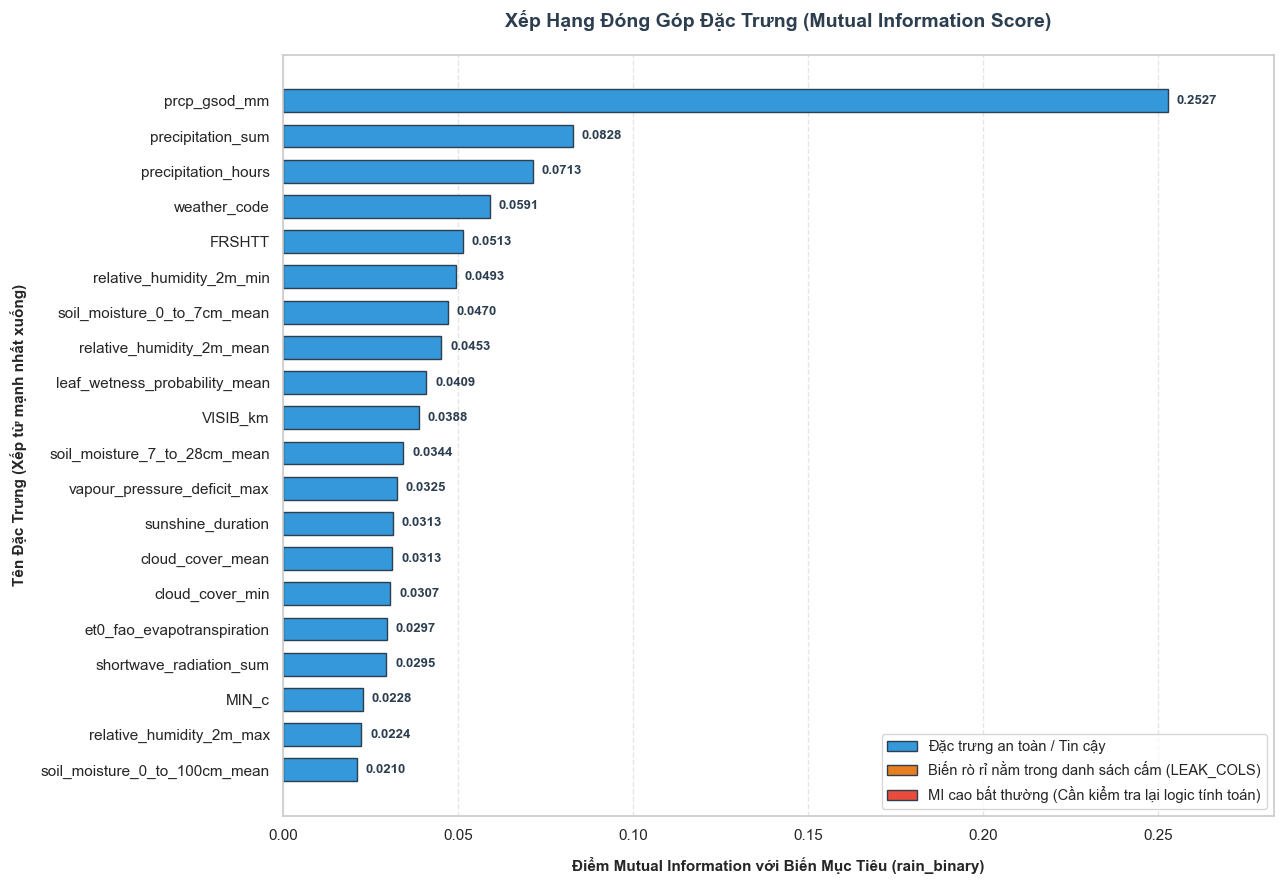

In [15]:
def plot_leakage_safeguard_mi_v3(df, top_n=20):
    """
    Biểu đồ 4 (Sửa lỗi gán màu): Sắp xếp DataFrame tăng dần trước khi vẽ barh,
    loại bỏ hoàn toàn lỗi gán màu do xung đột chỉ mục [[::-1]].
    """
    META_COLS = ['STATION', 'DATE']
    TARGET_COLS = ['rain_class', 'rain_binary', 'target_reliable']
    LEAK_COLS = ['target_reliable', 'imputed_from_om', 'prcp_mnar_station', 'slp_is_gsod', 'gust_observed']
    
    if 'rain_binary' not in df.columns:
        print("Yêu cầu cần có cột 'rain_binary' để tính toán.")
        return

    # 1. Trích xuất đặc trưng và tính toán MI
    df_clean = df.select_dtypes(include=[np.number, bool]).dropna()
    feature_cols = [c for c in df_clean.columns if c not in META_COLS and c not in TARGET_COLS]
    leak_present = [c for c in LEAK_COLS if c in df_clean.columns]
    feature_cols_with_leak = feature_cols + [c for c in leak_present if c not in feature_cols]
    
    X = df_clean[feature_cols_with_leak]
    y = df_clean['rain_binary']
    
    if X.shape[1] == 0:
        print("Không có đủ đặc trưng.")
        return

    print("Đang tính toán Mutual Information Score...")
    mi_scores = mutual_info_classif(X, y, random_state=42)
    
    # Tạo DataFrame kết quả ban đầu
    mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
    
    # Lấy top_n biến mạnh nhất (Sắp xếp giảm dần để lọc lấy Top)
    mi_df = mi_df.sort_values(by='MI_Score', ascending=False).head(top_n)
    
    # SẮP XẾP LẠI TĂNG DẦN để khi vẽ plt.barh(), biến mạnh nhất sẽ nằm ở TRÊN CÙNG
    mi_df = mi_df.sort_values(by='MI_Score', ascending=True).reset_index(drop=True)
    
    # 2. ĐỊNH DẠNG MÀU SẮC DỰA TRÊN DF ĐÃ SẮP XẾP CHUẨN
    colors = []
    for feat, score in zip(mi_df['Feature'], mi_df['MI_Score']):
        if feat in LEAK_COLS:
            colors.append('#E67E22')  # Cam đậm: Leak nằm trong danh sách cấm
        elif score > 0.7:
            colors.append('#E74C3C')  # Đỏ dịu: Nguy cơ rò rỉ rất cao (>0.7)
        else:
            colors.append('#3498DB')  # Xanh dương sáng: Đặc trưng an toàn
            
    mi_df['Color'] = colors

    # 3. CẤU HÌNH GIAO DIỆN & VẼ BIỂU ĐỒ (Không dùng [[::-1]] nữa)
    sns.set_theme(style="whitegrid")
    dynamic_height = max(6, top_n * 0.45) 
    plt.figure(figsize=(13, dynamic_height))
    
    # Vẽ trực tiếp bằng chuỗi dữ liệu đã đồng bộ chỉ mục
    bars = plt.barh(mi_df['Feature'], mi_df['MI_Score'], 
                    color=mi_df['Color'], edgecolor='#2C3E50', height=0.65)
    
    # Đường line cảnh báo nguy cơ rò rỉ dữ liệu
    max_score = mi_df['MI_Score'].max()
    plt.axvline(x=0.7, color='#C0392B', linestyle='--', alpha=0.6, linewidth=1.5)
    
    # 4. THÊM NHÃN GIÁ TRỊ SỐ (VALUE LABELS)
    for bar in bars:
        width = bar.get_width()
        if width > 0.002: # Hiện số nếu giá trị MI đủ lớn
            plt.text(width + (max_score * 0.01), 
                     bar.get_y() + bar.get_height()/2, 
                     f'{width:.4f}', 
                     va='center', ha='left', fontsize=9.5, fontweight='semibold', color='#2C3E50')

    # 5. THIẾT KẾ TIÊU ĐỀ & LEGEND GỌN GÀNG
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3498DB', edgecolor='#2C3E50', label='Đặc trưng an toàn / Tin cậy'),
        Patch(facecolor='#E67E22', edgecolor='#2C3E50', label='Biến rò rỉ nằm trong danh sách cấm (LEAK_COLS)'),
        Patch(facecolor='#E74C3C', edgecolor='#2C3E50', label='MI cao bất thường (Cần kiểm tra lại logic tính toán)')
    ]
    plt.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=10.5)
    
    plt.title('Xếp Hạng Đóng Góp Đặc Trưng (Mutual Information Score)', fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
    plt.xlabel('Điểm Mutual Information với Biến Mục Tiêu (rain_binary)', fontsize=11, fontweight='bold', labelpad=10)
    plt.ylabel('Tên Đặc Trưng (Xếp từ mạnh nhất xuống)', fontsize=11, fontweight='bold', labelpad=10)
    
    plt.grid(axis='y', linestyle='') 
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Tạo khoảng trống biên phải cho chữ số hiển thị đẹp mắt
    plt.xlim(0, max_score * 1.12)
    
    plt.tight_layout()
    plt.show()

# Gọi hàm thực thi lại trong Notebook của bạn:
plot_leakage_safeguard_mi_v3(train_repr, top_n=20)

## Chẩn đoán đa cộng tuyến và đánh giá độ trùng lặp thông tin của các thuộc tính khí tượng gốc

* **Thanh lọc và định nghĩa nhóm thuộc tính nền tảng (`get_base_cols`):** Thiết lập bộ lọc loại bỏ toàn bộ các biến phái sinh (lag, rolling, mã hóa vòng, cờ hiệu) và chỉ giữ lại nhóm thuộc tính số nguyên bản để làm dữ liệu đầu vào chuẩn cho các bài kiểm thử cấu trúc.
* **Sàng lọc ma trận tương quan tuyến tính (`Test 1: Correlation`):** Quét toàn bộ các cặp biến gốc nhằm phát hiện nhanh những cặp có hệ số tương quan tuyến tính vượt ngưỡng nghiêm trọng ($|r| > 0.90$), cô lập các nguồn thông tin bị trùng lặp trực tiếp.
* **Phân tích thành phần chính đánh giá độ dư thừa (`Test 2: PCA`):** Đo lường tổng lượng phương sai giải thích để xác định số lượng thành phần chính (`PCs`) cần thiết nhằm đại diện cho 95% thông tin của hệ thống, từ đó tính toán tỷ lệ dư thừa (`Redundancy ratio`) của tập dữ liệu gốc.
* **Bóc tách trọng số tải của các biến đại diện (`PCA Loading`):** Trích xuất và sắp xếp độ lớn các hệ số tải (`loadings`) trên các thành phần chính đầu tiên (đặc biệt là PC1), giúp nhận diện nhóm biến có sức ảnh hưởng chi phối nhất (thường là nhóm trường nhiệt độ).
* **Đo lường hệ số phóng đại phương sai (`Test 3: VIF`):** Thực hiện tính toán chỉ số VIF trên một tập mẫu ổn định nhằm phát hiện hiện tượng đa cộng tuyến đa biến (một biến bị giải thích bởi tổ hợp tuyến tính của nhiều biến khác) thông qua việc cô lập các thuộc tính có VIF > 10.
* **Đánh giá độ đồng thuận giữa hai nguồn dữ liệu độc lập (`Test 4: Cross-source`):** Tính toán hệ số tương quan trực tiếp giữa các cặp biến đồng dạng nhằm kiểm chuẩn chất lượng và độ tin cậy của nguồn dữ liệu bổ trợ.

In [16]:

# ── Định nghĩa nhóm cần test ──────────────────────────────────
# Chỉ lấy biến gốc (không lag, không roll, không OHE, không flag)
EXCLUDE_PATTERNS = [
    'lag', 'roll', '_sin', '_cos', 'koppen_', 'season_label_',
    'is_', 'gust_observed', 'slp_is_gsod', 'prcp_mnar',
    'imputed', 'target', 'rain_', 'STATION', 'DATE', 'NAME',
    'structural_gap', '_is_outlier', 'FRSHTT',
    'enso_phase_enc', 'enso_phase',  # giữ enso_mei_current thôi
]

def get_base_cols(df):
    cols = []
    for c in df.columns:
        if any(p in c for p in EXCLUDE_PATTERNS):
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

base_cols = get_base_cols(train_fe_final)
df_base = train_fe_final[base_cols].dropna()
print(f"Base cols để test: {len(base_cols)}")

# ── Test 1: Correlation matrix ────────────────────────────────
corr = df_base.corr()
# Tìm cặp |corr| > 0.90
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        c = corr.iloc[i, j]
        if abs(c) > 0.90:
            high_corr_pairs.append({
                'col_A': corr.columns[i],
                'col_B': corr.columns[j],
                'corr': round(c, 4)
            })
corr_df = pd.DataFrame(high_corr_pairs).sort_values('corr', key=abs, ascending=False)
print(f"\nCặp |corr| > 0.90: {len(corr_df)}")
print(corr_df.to_string(index=False))

# ── Test 2: PCA — xem bao nhiêu PC giải thích 95% variance ───
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_base)
pca = PCA().fit(X_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"\nPCA: {n_95} components giải thích 95% variance / {len(base_cols)} features")
print(f"→ Redundancy ratio: {1 - n_95/len(base_cols):.1%}")

# Top loading features của PC1, PC2 (thường là nhóm nhiệt độ)
loadings = pd.DataFrame(pca.components_[:3].T,
                         index=base_cols,
                         columns=['PC1','PC2','PC3'])
print("\nTop 10 loading |PC1|:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10))

# ── Test 3: VIF — chỉ chạy trên subset để tránh singular matrix
# Dùng sample 5000 rows, drop zero-variance
df_vif = df_base.sample(5000, random_state=42) if len(df_base) > 5000 else df_base
df_vif = df_vif.loc[:, df_vif.std() > 0]

vif_data = pd.DataFrame({
    'feature': df_vif.columns,
    'VIF': [variance_inflation_factor(df_vif.values, i)
            for i in range(df_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(f"\nVIF > 10 (multicollinear):")
print(vif_data[vif_data['VIF'] > 10].to_string(index=False))

# ── Test 4: Cross-source correlation (GSOD vs OM) ─────────────
cross_pairs = [
    ('TEMP_c',       'temperature_2m_mean'),
    ('MAX_c',        'temperature_2m_max'),
    ('MIN_c',        'temperature_2m_min'),
    ('DEWP_c',       'dew_point_2m_mean'),
    ('prcp_gsod_mm', 'precipitation_sum'),
    ('WDSP_kmh',     'wind_speed_10m_mean'),
    ('MXSPD_kmh',    'wind_speed_10m_max'),
    ('SLP_hpa',      'pressure_msl_mean'),
]
print("\nCross-source correlation (GSOD vs Open-Meteo):")
for a, b in cross_pairs:
    if a in train_fe_final.columns and b in train_fe_final.columns:
        r = train_fe_final[[a, b]].dropna().corr().iloc[0, 1]
        print(f"  {a:<20} vs {b:<25} r={r:.4f}")

Base cols để test: 75

Cặp |corr| > 0.90: 115
                         col_A                            col_B    corr
           wet_bulb_depression                        pseudo_li  1.0000
 soil_moisture_0_to_100cm_mean            soil_saturation_proxy  0.9998
                         month                      day_of_year  0.9965
             pressure_msl_mean                 pressure_msl_max  0.9949
             pressure_msl_mean                 pressure_msl_min  0.9936
             sunshine_duration                sunshine_fraction  0.9919
   wet_bulb_temperature_2m_min     wet_bulb_temperature_2m_mean  0.9870
   wet_bulb_temperature_2m_max     wet_bulb_temperature_2m_mean  0.9867
              dew_point_2m_min                dew_point_2m_mean  0.9851
      apparent_temperature_min      wet_bulb_temperature_2m_min  0.9849
             dew_point_2m_mean     wet_bulb_temperature_2m_mean  0.9845
              dew_point_2m_max      wet_bulb_temperature_2m_max  0.9841
              pres

## Drop cột dư thừa

In [17]:
# =============================================================================
# FINALIZE DATASET — DROP REDUNDANT COLUMNS
# =============================================================================

DROP_FINAL = [
    # Nhiệt độ OM thừa khi đã có GSOD
    'temperature_2m_max', 'temperature_2m_min',
    'apparent_temperature_max', 'apparent_temperature_min',
    'soil_temperature_0_to_100cm_mean',

    # Độ ẩm/điểm sương min/max thừa
    'dew_point_2m_max', 'dew_point_2m_min',
    'relative_humidity_2m_min',
    'wet_bulb_temperature_2m_max', 'wet_bulb_temperature_2m_min',
    'pseudo_li',

    # Mưa
    'precipitation_probability_mean', 'precipitation_probability_min',
    'snowfall_sum', 'snowfall_water_equivalent_sum',

    # Gió
    'wind_speed_10m_min', 'wind_gusts_10m_mean', 'wind_gusts_10m_min',

    # Áp suất
    'pressure_msl_max', 'pressure_msl_min',

    # Bức xạ derived
    'sunshine_fraction', 'radiation_deficit',

    # Đất derived/redundant
    'soil_moisture_7_to_28cm_mean',
    'soil_moisture_depth_gradient', 'soil_saturation_proxy',

    # CAPE
    'cape_min',

    # Temporal
    'day_of_month', 'week_of_year',
    'enso_phase_enc', 'elevation_category',

    # Visibility
    'visibility_om_km',

    "koppen_Af",
]

def finalize_splits(train_fe_final, val_fe_final, test_fe_final,
                    new_folds_fe_final, drop_cols=DROP_FINAL):

    # Chỉ drop những cột thực sự tồn tại
    def _drop(df):
        to_drop = [c for c in drop_cols if c in df.columns]
        return df.drop(columns=to_drop)

    train_fin = _drop(train_fe_final)
    val_fin   = _drop(val_fe_final)
    test_fin  = _drop(test_fe_final)

    folds_fin = [(_drop(tr), _drop(vl)) for tr, vl in new_folds_fe_final]

    print("=" * 55)
    print("FINALIZE — DROP REDUNDANT COLUMNS")
    print("=" * 55)
    print(f"  Dropped      : {len([c for c in drop_cols if c in train_fe_final.columns])} cols")
    print(f"  train_fin    : {train_fin.shape}")
    print(f"  val_fin      : {val_fin.shape}")
    print(f"  test_fin     : {test_fin.shape}")
    print(f"  Folds        : {len(folds_fin)}")

    # Sanity check — column alignment giữa các splits
    ref = set(train_fin.columns)
    for name, df in [('val', val_fin), ('test', test_fin)]:
        diff = set(df.columns) ^ ref
        if diff:
            print(f"  ⚠ {name} column mismatch: {diff}")
        else:
            print(f"  ✓ {name} columns aligned")

    return train_fin, val_fin, test_fin, folds_fin


train_fin, val_fin, test_fin, folds_fin = finalize_splits(
    train_fe_final, val_fe_final, test_fe_final, new_folds_fe_final
)

FINALIZE — DROP REDUNDANT COLUMNS
  Dropped      : 25 cols
  train_fin    : (43830, 105)
  val_fin      : (5475, 105)
  test_fin     : (5490, 105)
  Folds        : 5
  ✓ val columns aligned
  ✓ test columns aligned


## Kiểm chuẩn chất lượng dữ liệu (Sanity Check)

* **Khóa tổ hợp (`1.1 Duplicate`):** Đếm số lượng bản ghi trùng lặp cặp khóa (`STATION`, `DATE`) để đảm bảo tính duy nhất của thực thể thời gian.
* **Biến hằng số (`1.2 Zero-variance`):** Cô lập các thuộc tính số có độ lệch chuẩn bằng 0 nhằm loại bỏ các biến không mang thông tin phân tách.
* **Tỷ lệ khuyết thiếu (`1.3 High NaN`):** Phát hiện và liệt kê các cột chứa trên $20\%$ dữ liệu rỗng gây nguy cơ sai lệch mô hình.
* **Tính liên tục chuỗi (`1.4 Date continuity`):** Truy vết các khoảng trống mất dữ liệu vượt quá 7 ngày liên tiếp theo từng trạm để kiểm soát lỗi tính toán biến trễ.
* **Phân phối nhãn nhị phân (`1.5 rain_binary`):** Theo dõi tỷ lệ phân bổ lớp nhị phân để giám sát mức độ mất cân bằng dữ liệu giữa các tập.
* **Phân phối nhãn đa lớp (`1.5 rain_class`):** Thống kê mật độ phân hạng 4 cấp độ lượng mưa nhằm bảo đảm tính đồng nhất phân phối trước khi huấn luyện.

In [18]:
def sanity_check(df, name='train'):
    print(f"\n{'='*50}")
    print(f"SANITY CHECK — {name}  {df.shape}")
    print(f"{'='*50}")

    # 1.1 Duplicate
    dup = df.duplicated(['STATION','DATE']).sum()
    print(f"  Duplicates (STATION,DATE) : {dup}")

    # 1.2 Zero-variance cols
    zv = [c for c in df.select_dtypes('number').columns
          if df[c].std() == 0]
    print(f"  Zero-variance cols        : {zv}")

    # 1.3 High NaN (>20%)
    nan_pct = df.isnull().mean()
    high_nan = nan_pct[nan_pct > 0.2].sort_values(ascending=False)
    print(f"  High NaN (>20%) cols      : {len(high_nan)}")
    if len(high_nan): print(high_nan)

    # 1.4 Date continuity per station
    gaps = []
    for st, grp in df.groupby('STATION'):
        dates = grp['DATE'].sort_values()
        diff = dates.diff().dt.days.dropna()
        max_gap = diff.max()
        if max_gap > 7:
            gaps.append({'station': st, 'max_gap_days': max_gap})
    if gaps:
        print(f"  Stations với gap > 7 ngày : {pd.DataFrame(gaps)}")
    else:
        print(f"  Date continuity           : ✓ No gap > 7 days")

    # 1.5 Target distribution
    if 'rain_binary' in df.columns:
        rb = df['rain_binary'].value_counts(normalize=True, dropna=True)
        print(f"  rain_binary distribution  : {rb.to_dict()}")
    if 'rain_class' in df.columns:
        rc = df['rain_class'].value_counts(normalize=True, dropna=True)
        print(f"  rain_class distribution   : {rc.to_dict()}")

sanity_check(train_fin, 'TRAIN')
sanity_check(val_fin,   'VAL')
sanity_check(test_fin,  'TEST')


SANITY CHECK — TRAIN  (43830, 105)
  Duplicates (STATION,DATE) : 0
  Zero-variance cols        : []
  High NaN (>20%) cols      : 0
  Date continuity           : ✓ No gap > 7 days
  rain_binary distribution  : {np.int64(0): 0.9303708047876736, np.int64(1): 0.0696291952123264}
  rain_class distribution   : {np.int64(0): 0.6140004798336577, np.int64(1): 0.3579825660437715, np.int64(2): 0.028016954122570843}

SANITY CHECK — VAL  (5475, 105)
  Duplicates (STATION,DATE) : 0
  Zero-variance cols        : ['year']
  High NaN (>20%) cols      : 0
  Date continuity           : ✓ No gap > 7 days
  rain_binary distribution  : {np.int64(0): 0.9340519974635384, np.int64(1): 0.06594800253646163}
  rain_class distribution   : {np.int64(0): 0.6100190234622701, np.int64(1): 0.3639822447685479, np.int64(2): 0.02599873176918199}

SANITY CHECK — TEST  (5490, 105)
  Duplicates (STATION,DATE) : 0
  Zero-variance cols        : ['year']
  High NaN (>20%) cols      : 0
  Date continuity           : ✓ No gap >

In [19]:
PHYSICAL_BOUNDS = {
    'TEMP_c'                  : (-10, 50),
    'MAX_c'                   : (-10, 50),
    'MIN_c'                   : (-10, 50),
    'relative_humidity_2m_mean': (0, 100),
    'relative_humidity_2m_max' : (0, 100),
    'prcp_gsod_mm'            : (0, 500),
    'precipitation_sum'       : (0, 600),
    'pressure_msl_mean'       : (950, 1060),
    'wind_speed_10m_mean'     : (0, 150),
    'wind_gusts_10m_max'      : (0, 200),
    'cloud_cover_mean'        : (0, 100),
    'sunshine_duration'       : (0, 50000),
    'soil_moisture_0_to_7cm_mean' : (0, 1),
}

def physical_check(df):
    print(f"\n{'='*50}")
    print("PHYSICAL PLAUSIBILITY CHECK")
    print(f"{'='*50}")
    for col, (lo, hi) in PHYSICAL_BOUNDS.items():
        if col not in df.columns:
            continue
        n_out = ((df[col] < lo) | (df[col] > hi)).sum()
        if n_out > 0:
            print(f"  ⚠ {col:<35} {n_out} rows out of [{lo}, {hi}]")
        else:
            print(f"  ✓ {col:<35} OK")

physical_check(train_fin)


PHYSICAL PLAUSIBILITY CHECK
  ✓ TEMP_c                              OK
  ✓ MAX_c                               OK
  ✓ MIN_c                               OK
  ✓ relative_humidity_2m_mean           OK
  ✓ relative_humidity_2m_max            OK
  ✓ prcp_gsod_mm                        OK
  ✓ precipitation_sum                   OK
  ✓ pressure_msl_mean                   OK
  ✓ wind_speed_10m_mean                 OK
  ✓ wind_gusts_10m_max                  OK
  ✓ cloud_cover_mean                    OK
  ✓ sunshine_duration                   OK
  ✓ soil_moisture_0_to_7cm_mean         OK


## Kiểm tra lại các ngưỡng vật lý

In [20]:
def temporal_check(train, val, test):
    print(f"\n{'='*50}")
    print("TEMPORAL SPLIT CHECK")
    print(f"{'='*50}")
    print(f"  Train : {train['DATE'].min().date()} → {train['DATE'].max().date()}")
    print(f"  Val   : {val['DATE'].min().date()}   → {val['DATE'].max().date()}")
    print(f"  Test  : {test['DATE'].min().date()}  → {test['DATE'].max().date()}")

    overlap_tv = set(train['DATE']) & set(val['DATE'])
    overlap_vt = set(val['DATE'])   & set(test['DATE'])
    print(f"  Train∩Val overlap : {len(overlap_tv)} dates")
    print(f"  Val∩Test overlap  : {len(overlap_vt)} dates")

temporal_check(train_fin, val_fin, test_fin)


TEMPORAL SPLIT CHECK
  Train : 2015-01-01 → 2022-12-31
  Val   : 2023-01-01   → 2023-12-31
  Test  : 2024-01-01  → 2024-12-31
  Train∩Val overlap : 0 dates
  Val∩Test overlap  : 0 dates


## Kiểm tra dữ liệu các trạm 

In [21]:
def station_check(train, val, test):
    print(f"\n{'='*50}")
    print("STATION COVERAGE CHECK")
    print(f"{'='*50}")
    tr_st = set(train['STATION'].unique())
    vl_st = set(val['STATION'].unique())
    te_st = set(test['STATION'].unique())
    print(f"  Train stations : {len(tr_st)}")
    print(f"  Val   stations : {len(vl_st)}")
    print(f"  Test  stations : {len(te_st)}")
    print(f"  Val  not in Train : {vl_st - tr_st}")
    print(f"  Test not in Train : {te_st - tr_st}")

    # Rows per station
    print(f"\n  Rows per station (train):")
    print(train.groupby('STATION')['DATE'].count().sort_values())

station_check(train_fin, val_fin, test_fin)


STATION COVERAGE CHECK
  Train stations : 15
  Val   stations : 15
  Test  stations : 15
  Val  not in Train : set()
  Test not in Train : set()

  Rows per station (train):
STATION
48820099999    2922
48823099999    2922
48826099999    2922
48831099999    2922
48840099999    2922
48845099999    2922
48848099999    2922
48852099999    2922
48863099999    2922
48866099999    2922
48870099999    2922
48894099999    2922
48900099999    2922
48907099999    2922
48914099999    2922
Name: DATE, dtype: int64


## Kiểm tra rò rỉ dữ liệu 

* **Cơ chế phòng vệ (`final_leakage_check`):** Kiểm quét toàn bộ tập thuộc tính số nhằm phát hiện sớm các biến phái sinh vô tình chứa thông tin của tương lai hoặc biến đổi tuyến tính từ nhãn.
* **Chuẩn hóa vùng đích (`Target Isolation`):** Cách ly tập dữ liệu trên các dòng có nhãn tin cậy (`target_reliable`), đồng thời ép kiểu số cho biến mục tiêu `rain_binary` để tính toán toán tử tương quan.
* **Lọc bỏ vùng nhiễu (`Feature Exclusion`):** Thiết lập mảng loại trừ (`EXCLUDE`) chứa thông tin định danh và các biến mục tiêu trực tiếp nhằm tập trung kiểm tra các thuộc tính đầu vào của mô hình.
* **Quét tương quan tuyến tính (`Correlation Scanning`):** Tính toán hệ số tương quan tuyến tính Pearson ($r$) giữa từng đặc trưng đầu vào với nhãn mục tiêu trên cùng một ngày.
* **Ngưỡng cảnh báo nguy hiểm (`Danger Threshold`):** Đặt ranh giới chặn $|r| > 0.7$ để cô lập và lập danh sách các thuộc tính có nguy cơ rò rỉ thông tin nghiêm trọng.
* **Xác nhận trạng thái lưới lọc (`Pipeline Sign-off`):** Đảm bảo không có đặc trưng nào vượt ngưỡng để phê duyệt tập dữ liệu đạt chuẩn an toàn trước khi đưa vào huấn luyện mô hình.

In [23]:
def final_leakage_check(df):
    """Đảm bảo không có biến nào là linear transform của target."""
    print(f"\n{'='*50}")
    print("FINAL LEAKAGE CHECK")
    print(f"{'='*50}")
    TARGET = 'rain_binary'
    EXCLUDE = ['STATION','DATE','NAME','rain_class','rain_binary',
               'prcp_gsod_mm','target_reliable']

    sub = df[df['target_reliable'].fillna(False).astype(bool)].copy() if 'target_reliable' in df.columns else df
    sub[TARGET] = pd.to_numeric(sub[TARGET], errors='coerce')
    y = sub[TARGET].dropna()

    feat_cols = [c for c in df.columns
                 if c not in EXCLUDE
                 and pd.api.types.is_numeric_dtype(df[c])]

    danger = []
    for col in feat_cols:
        x = sub.loc[y.index, col].fillna(0)
        if x.std() == 0: continue
        r = abs(float(np.corrcoef(x, y)[0,1]))
        if r > 0.7:
            danger.append({'col': col, 'corr': round(r, 4)})

    if danger:
        print(f"  ❌ Corr > 0.7 với target:")
        for d in sorted(danger, key=lambda x: -x['corr']):
            print(f"     {d['col']:<40} r={d['corr']}")
    else:
        print(f"  ✓ Không có feature nào corr > 0.7 với rain_binary")

final_leakage_check(train_fin)


FINAL LEAKAGE CHECK
  ✓ Không có feature nào corr > 0.7 với rain_binary


In [25]:
from pathlib import Path
import pandas as pd

# ---------------------------------------------------------------------
# 1. ĐỊNH NGHĨA THƯ MỤC LƯU KẾT QUẢ
# ---------------------------------------------------------------------
DATA_DIR = Path("../data/processed/feature engineered")
FOLDS_DIR = DATA_DIR / "folds"

# Tạo các thư mục nếu chưa tồn tại
DATA_DIR.mkdir(parents=True, exist_ok=True)
FOLDS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 65)
print("PROCESSING, CONCATENATING & SAVING DATA ARTIFACTS")
print("=" * 65)

# ---------------------------------------------------------------------
# 2. GỘP 3 TẬP ĐẠI DIỆN VÀ LƯU THÀNH DF_CODEBOOK_FINAL
# ---------------------------------------------------------------------
print("\n[1/3] Concatenating Train, Val, Test and saving final dataset...")

# Gộp 3 DataFrame theo hàng (axis=0), bỏ qua index cũ để tạo index mới liên tục
df_all_fin = pd.concat(
    [train_fin, val_fin, test_fin],
    axis=0,
    ignore_index=True
)

# Lưu Parquet
df_all_fin.to_parquet(
    DATA_DIR / "df_codebook_final.parquet",
    index=False
)

print(f"  ✓ Successfully concatenated {len(df_all_fin):,} rows.")
print("  ✓ Saved df_codebook_final.parquet")

# ---------------------------------------------------------------------
# 3. LƯU RIÊNG CÁC TẬP ĐẠI DIỆN
# ---------------------------------------------------------------------
print("\n[2/3] Saving representative splits...")

train_fin.to_parquet(
    DATA_DIR / "train_representative.parquet",
    index=False
)

val_fin.to_parquet(
    DATA_DIR / "val_representative.parquet",
    index=False
)

test_fin.to_parquet(
    DATA_DIR / "test_final.parquet",
    index=False
)

print("  ✓ Saved train_representative.parquet")
print("  ✓ Saved val_representative.parquet")
print("  ✓ Saved test_final.parquet")

# ---------------------------------------------------------------------
# 4. KIỂM TRA TRÙNG CỘT VÀ LƯU TOÀN BỘ K-FOLD
# ---------------------------------------------------------------------
print(f"\n[3/3] Checking duplicates and saving {len(folds_fin)} K-Fold splits...")

for fold_idx, (fold_train, fold_val) in enumerate(folds_fin):

    # Loại bỏ các cột trùng tên nếu có
    if fold_train.columns.duplicated().any():
        fold_train = fold_train.loc[:, ~fold_train.columns.duplicated()]

    if fold_val.columns.duplicated().any():
        fold_val = fold_val.loc[:, ~fold_val.columns.duplicated()]

    fold_train.to_parquet(
        FOLDS_DIR / f"fold_{fold_idx}_train.parquet",
        index=False
    )

    fold_val.to_parquet(
        FOLDS_DIR / f"fold_{fold_idx}_val.parquet",
        index=False
    )

print(f"  ✓ Saved {len(folds_fin)} K-Fold splits into '{FOLDS_DIR}'")

print("\n" + "=" * 65)
print("ALL TASKS COMPLETED SUCCESSFULLY!")
print("=" * 65)

print("\nGenerated files:")
print("  df_codebook_final.parquet")
print("  train_representative.parquet")
print("  val_representative.parquet")
print("  test_final.parquet")
print("  folds/")
for i in range(len(folds_fin)):
    print(f"    fold_{i}_train.parquet")
    print(f"    fold_{i}_val.parquet")

PROCESSING, CONCATENATING & SAVING DATA ARTIFACTS

[1/3] Concatenating Train, Val, Test and saving final dataset...
  ✓ Successfully concatenated 54,795 rows.
  ✓ Saved df_codebook_final.parquet

[2/3] Saving representative splits...
  ✓ Saved train_representative.parquet
  ✓ Saved val_representative.parquet
  ✓ Saved test_final.parquet

[3/3] Checking duplicates and saving 5 K-Fold splits...
  ✓ Saved 5 K-Fold splits into '..\data\processed\feature engineered\folds'

ALL TASKS COMPLETED SUCCESSFULLY!

Generated files:
  df_codebook_final.parquet
  train_representative.parquet
  val_representative.parquet
  test_final.parquet
  folds/
    fold_0_train.parquet
    fold_0_val.parquet
    fold_1_train.parquet
    fold_1_val.parquet
    fold_2_train.parquet
    fold_2_val.parquet
    fold_3_train.parquet
    fold_3_val.parquet
    fold_4_train.parquet
    fold_4_val.parquet


In [26]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# ============================================================
# METADATA: Description & Note cho từng cột của df_full_processed
# ============================================================
COLUMN_METADATA = {
    "STATION": {
        "description": "Mã trạm khí tượng gốc (USAF).",
        "source/note": "Loại bản ghi lặp (STATION, DATE), giữ dòng cao nhất theo TEMP_ATTRIBUTES.",
    },
    "DATE": {
        "description": "Ngày quan sát khí tượng.",
        "source/note": "Chuẩn hóa datetime64[ns] timezone-naive, bỏ giờ/phút/giây (00:00:00).",
    },
    "LATITUDE": {
        "description": "Vĩ độ trạm khí tượng.",
        "source/note": "",
    },
    "LONGITUDE": {
        "description": "Kinh độ trạm khí tượng.",
        "source/note": "",
    },
    "ELEVATION": {
        "description": "Độ cao của trạm so với mực nước biển (mét).",
        "source/note": "",
    },
    "NAME": {
        "description": "Tên quốc tế của trạm khí tượng (tiếng Anh).",
        "source/note": "",
    },
    "FRSHTT": {
        "description": "Mã nhị phân tổng hợp các hiện tượng thời tiết trong ngày (Sương mù, Mưa, Tuyết, Mưa đá, Sấm sét, Lốc xoáy).",
        "source/note": "",
    },

    # ── Open-Meteo gốc ────────────────────────────────────────────────────────
    "precipitation_sum": {
        "description": "Tổng lượng mưa tích lũy trong ngày (mm).",
        "source/note": "Giúp điền khuyết prcp_gsod_mm when target_reliable == True.",
    },
    "precipitation_hours": {
        "description": "Tổng số giờ có lượng mưa > 0.1 mm trong ngày.",
        "source/note": "",
    },
    "temperature_2m_mean": {
        "description": "Nhiệt độ không khí trung bình ngày đo ở độ cao 2m (°C).",
        "source/note": "Hỗ trợ MICE và tính các biến phái sinh nhiệt động lực học.",
    },
    "apparent_temperature_mean": {
        "description": "Cảm giác nhiệt độ trung bình ngày (°C).",
        "source/note": "",
    },
    "dew_point_2m_mean": {
        "description": "Nhiệt độ điểm sương trung bình ngày ở độ cao 2m (°C).",
        "source/note": "Giúp điền khuyết DEWP_c theo Cross-source Fill.",
    },
    "wet_bulb_temperature_2m_mean": {
        "description": "Nhiệt độ bầu ướt trung bình ngày ở độ cao 2m, giới hạn làm mát bằng bay hơi (°C).",
        "source/note": "",
    },
    "relative_humidity_2m_max": {
        "description": "Độ ẩm tương đối không khí cực đại trong ngày ở độ cao 2m (%).",
        "source/note": "",
    },
    "relative_humidity_2m_mean": {
        "description": "Độ ẩm tương đối không khí trung bình ngày ở độ cao 2m (%).",
        "source/note": "",
    },
    "vapour_pressure_deficit_max": {
        "description": "Thâm hụt áp suất hơi nước lớn nhất trong ngày (chênh lệch giữa áp suất hơi bão hòa và thực tế) (kPa).",
        "source/note": "",
    },
    "leaf_wetness_probability_mean": {
        "description": "Xác suất trung bình ngày có nước đọng trên bề mặt lá cây (%).",
        "source/note": "",
    },
    "pressure_msl_mean": {
        "description": "Áp suất khí quyển trung bình ngày quy về mực nước biển (hPa).",
        "source/note": "",
    },
    "surface_pressure_mean": {
        "description": "Áp suất khí quyển thực tế trung bình ngày tại cao độ của trạm (hPa).",
        "source/note": "",
    },
    "wind_speed_10m_max": {
        "description": "Tốc độ gió cao nhất trong ngày đo ở độ cao 10 mét (km/h).",
        "source/note": "Giúp điền khuyết MXSPD_kmh theo Cross-source fill.",
    },
    "wind_gusts_10m_max": {
        "description": "Tốc độ gió giật mạnh nhất trong ngày ở độ cao 10 mét (km/h).",
        "source/note": "",
    },
    "wind_direction_10m_dominant": {
        "description": "Hướng gió chủ đạo trong ngày ở độ cao 10m (0–360°, 360° là hướng Bắc).",
        "source/note": "",
    },
    "wind_speed_10m_mean": {
        "description": "Tốc độ gió trung bình ngày ở độ cao 10m (km/h).",
        "source/note": "Được dùng để điền khuyết WDSP_kmh theo quy tắc Cross-source Fill.",
    },
    "shortwave_radiation_sum": {
        "description": "Tổng năng lượng bức xạ mặt trời sóng ngắn nhận được trong ngày trên một mét vuông (MJ/m²).",
        "source/note": "",
    },
    "cloud_cover_mean": {
        "description": "Tỷ lệ mây che phủ bầu trời trung bình ngày (%).",
        "source/note": "",
    },
    "cloud_cover_max": {
        "description": "Tỷ lệ mây che phủ bầu trời lớn nhất trong ngày (%).",
        "source/note": "",
    },
    "cloud_cover_min": {
        "description": "Tỷ lệ mây che phủ bầu trời nhỏ nhất trong ngày (%).",
        "source/note": "",
    },
    "sunshine_duration": {
        "description": "Tổng số giây có ánh nắng mặt trời trực tiếp trong ngày.",
        "source/note": "",
    },
    "daylight_duration": {
        "description": "Thời gian ban ngày tính từ lúc mặt trời mọc đến khi lặn (giây).",
        "source/note": "",
    },
    "et0_fao_evapotranspiration": {
        "description": "Lượng thoát hơi nước tiềm năng chuẩn theo công thức FAO-56 Penman-Monteith (mm).",
        "source/note": "",
    },
    "soil_moisture_0_to_7cm_mean": {
        "description": "Độ ẩm đất trung bình ngày ở tầng nông 0–7 cm (tỷ lệ thể tích nước/đất) (m³/m³).",
        "source/note": "",
    },
    "soil_moisture_28_to_100cm_mean": {
        "description": "Độ ẩm đất trung bình ngày ở tầng rễ sâu 28–100 cm (m³/m³).",
        "source/note": "",
    },
    "soil_moisture_0_to_100cm_mean": {
        "description": "Độ ẩm đất trung bình ngày toàn bộ tầng rễ sâu 1 mét (0–100 cm) (m³/m³).",
        "source/note": "",
    },
    "soil_temperature_0_to_7cm_mean": {
        "description": "Nhiệt độ đất trung bình ngày ở tầng bề mặt 0–7 cm (°C).",
        "source/note": "",
    },
    "weather_code": {
        "description": "Mã hiện tượng thời tiết theo chuẩn WMO (World Meteorological Organization).",
        "source/note": "",
    },

    # ── Cột phái sinh từ GSOD ─────────────────────────────────────────────────
    "TEMP_c": {
        "description": "Nhiệt độ trung bình ngày quy đổi sang Celsius (°C).",
        "source/note": "Quy đổi từ Fahrenheit sang Celsius theo công thức C = (F − 32) × 5/9. Sentinel value --> NaN.",
    },
    "DEWP_c": {
        "description": "Nhiệt độ điểm sương trung bình ngày quy đổi sang Celsius (°C).",
        "source/note": "Sentinel value 9999.9 --> NaN. Cross-source Fill từ dew_point_2m_mean (Open-Meteo); áp ngưỡng miền vật lý [−30.0, 40.0].",
    },
    "MAX_c": {
        "description": "Nhiệt độ không khí cao nhất trong ngày quy đổi sang Celsius (°C).",
        "source/note": "Sentinel value 9999.9 --> NaN. Cross-source Fill từ temperature_2m_max (Open-Meteo); áp ngưỡng miền vật lý [−20.0, 50.0].",
    },
    "MIN_c": {
        "description": "Nhiệt độ không khí thấp nhất trong ngày quy đổi sang Celsius (°C).",
        "source/note": "Sentinel value 9999.9 --> NaN. Cross-source Fill từ temperature_2m_min (Open-Meteo); áp ngưỡng miền vật lý [−20.0, 45.0].",
    },
    "prcp_gsod_mm": {
        "description": "Lượng mưa tổng ngày từ GSOD quy đổi sang mm (mm).",
        "source/note": "Sentinel value 99.99 inches --> NaN. Cross-source Fill từ precipitation_sum (Open-Meteo) khi target_reliable == True; các ô còn lại xử lý bằng MICE (BayesianRidge, fit trên tập train), áp ngưỡng miền vật lý (≥ 0.0).",
    },
    "WDSP_kmh": {
        "description": "Tốc độ gió trung bình ngày quy đổi sang km/h (km/h).",
        "source/note": "Sentinel value 999.9 knots --> NaN. Cross-source Fill từ wind_speed_10m_mean (Open-Meteo); áp ngưỡng miền vật lý (≥ 0.0).",
    },
    "MXSPD_kmh": {
        "description": "Tốc độ gió tối đa trong ngày quy đổi sang km/h (km/h).",
        "source/note": "Sentinel value 999.9 knots --> NaN. Cross-source Fill từ wind_speed_10m_max (Open-Meteo); áp ngưỡng miền vật lý (≥ 0.0).",
    },
    "VISIB_km": {
        "description": "Tầm nhìn xa trung bình ngày quy đổi sang km (km).",
        "source/note": "Sentinel value 999.9 miles --> NaN. Giá trị khuyết xử lý bằng MICE (BayesianRidge, fit trên tập train); các ô còn sót lại điền bằng median fallback từ tập train, áp ngưỡng miền vật lý (≥ 0.0).",
    },

    # ── Cờ chất lượng & metadata trạm ────────────────────────────────────────
    "gust_observed": {
        "description": "Cờ nhị phân xác nhận trạm có ghi nhận gió giật thực đo trong ngày (1 = có, 0 = không).",
        "source/note": "Cột mới tạo trong bước kiểm tra chất lượng dữ liệu GSOD.",
    },
    "slp_is_gsod": {
        "description": "Cờ nhị phân đánh dấu giá trị áp suất mực biển (SLP) lấy từ nguồn GSOD thay vì Open-Meteo (1 = GSOD, 0 = Open-Meteo).",
        "source/note": "Cột mới tạo trong bước tích hợp hai nguồn dữ liệu.",
    },
    "prcp_mnar_station": {
        "description": "Cờ nhị phân xác định dữ liệu lượng mưa bị khuyết không ngẫu nhiên do trạm không có thiết bị đo mưa (MNAR). 1 = trạm không có thiết bị đo, 0 = trạm có thiết bị đo.",
        "source/note": "Cột mới tạo trong bước phân tích cơ chế khuyết dữ liệu.",
    },
    "imputed_from_om": {
        "description": "Cờ logic đánh dấu Cross-source Fill từ Open-Meteo (True = đã điền từ Open-Meteo, False = dữ liệu gốc/ không điền).",
        "source/note": "",
    },

    # ── Biến mục tiêu ─────────────────────────────────────────────────────────
    "target_reliable": {
        "description": "Biến logic xác thực độ tin cậy của dòng dữ liệu mưa, 1 - trạm có thiết bị đo mưa và không dính lỗi hệ thốngmcndacbedcfeba.",
        "source/note": "Target Variable: Dùng làm điều kiện lọc khi gán nhãn rain_class và rain_binary; cũng là điều kiện để điền khuyết prcp_gsod_mm từ Open-Meteo.",
    },
    "rain_class": {
        "description": "Nhãn phân lớp mưa đa lớp (Int64): Lớp 0 – không mưa (< 0.1 mm), Lớp 1 – mưa thường (0.1–50 mm), Lớp 2 – mưa cực đoan (≥ 50 mm), NA khi target_reliable == False.",
        "source/note": "Target Variable: Ngưỡng phân lớp theo chuẩn WMO. 5818 giá trị NA tương ứng với các dòng target_reliable == False.",
    },
    "rain_binary": {
        "description": "Biến nhị phân phụ trợ phân tách mưa lớn: 1 nếu prcp_gsod_mm ≥ 25 mm. Trả về NA khi target_reliable == False.",
        "source/note": "Target Variable: phụ trợ trong mô hình hóa. 5818 giá trị NA tương ứng với các dòng target_reliable == False.",
    },

    # ── Biến thời gian ────────────────────────────────────────────────────────
    "year": {
        "description": "Năm của ngày quan sát, trích xuất từ cột DATE.",
        "source/note": "Feature Engineer: bằng dt.year. Cột trung gian YEAR dùng để chia tập đã bị xóa sau khi hoàn tất phân chia.",
    },
    "month": {
        "description": "Tháng của ngày quan sát (1–12), trích xuất từ cột DATE.",
        "source/note": "Feature Engineer: bằng dt.month.",
    },
    "day_of_year": {
        "description": "Thứ tự ngày trong năm (1–366), trích xuất từ cột DATE.",
        "source/note": "Feature Engineer: bằng dt.dayofyear.",
    },
    "month_sin": {
        "description": "Mã hóa vòng tuần hoàn tháng theo chiều sin: sin(2π × month / 12), tránh ngắt quãng tại ranh giới tháng 12–1.",
        "source/note": "Feature Engineer",
    },
    "month_cos": {
        "description": "Mã hóa vòng tuần hoàn tháng theo chiều cos: cos(2π × month / 12), tránh ngắt quãng tại ranh giới tháng 12–1.",
        "source/note": "Feature Engineer",
    },
    "doy_sin": {
        "description": "Mã hóa vòng tuần hoàn ngày trong năm theo chiều sin: sin(2π × day_of_year / 365.25).",
        "source/note": "Feature Engineer",
    },
    "doy_cos": {
        "description": "Mã hóa vòng tuần hoàn ngày trong năm theo chiều cos: cos(2π × day_of_year / 365.25).",
        "source/note": "Feature Engineer",
    },
    "is_monsoon": {
        "description": "Biến nhị phân xác định mùa mưa (1 = mùa mưa, 0 = mùa khô) dựa theo vùng khí hậu của trạm: Bắc (tháng 5–10), Trung (tháng 9–12), Nam (tháng 5–11).",
        "source/note": "Feature Engineer",
    },

    # ── Biến ENSO ─────────────────────────────────────────────────────────────
    "enso_mei_current": {
        "description": "Giá trị chỉ số MEI (Multivariate ENSO Index) của tháng/năm hiện tại, lấy từ NOAA.",
        "source/note": "Feature Engineer: Nguồn dữ liệu ngoại sinh: NOAA MEI.",
    },
    "enso_mei_3m_lag": {
        "description": "Giá trị chỉ số MEI của 3 tháng trước đó, phản ánh trạng thái ENSO có độ trễ.",
        "source/note": "Feature Engineer: Nguồn dữ liệu ngoại sinh: NOAA MEI.",
    },
    "enso_phase": {
        "description": "Chuỗi phân loại pha ENSO dựa trên enso_mei_current: 'el_nino' (> 0.5), 'la_nina' (< −0.5), 'neutral' (còn lại).",
        "source/note": "",
    },

    # ── Biến trễ (Lag) ────────────────────────────────────────────────────────
    "prcp_gsod_mm_lag1": {
        "description": "Lượng mưa GSOD (mm) của ngày T−1 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(1) theo nhóm STATION sau khi sắp xếp tăng dần theo DATE. 7 hàng đầu tiên của mỗi trạm bị loại bỏ (MAX_LAG_K = 7).",
    },
    "prcp_gsod_mm_lag2": {
        "description": "Lượng mưa GSOD (mm) của ngày T−2 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(2) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "prcp_gsod_mm_lag3": {
        "description": "Lượng mưa GSOD (mm) của ngày T−3 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(3) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "prcp_gsod_mm_lag7": {
        "description": "Lượng mưa GSOD (mm) của ngày T−7 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(7) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "precipitation_sum_lag1": {
        "description": "Tổng lượng mưa Open-Meteo (mm) của ngày T−1 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(1) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "precipitation_sum_lag3": {
        "description": "Tổng lượng mưa Open-Meteo (mm) của ngày T−3 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(3) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "precipitation_sum_lag7": {
        "description": "Tổng lượng mưa Open-Meteo (mm) của ngày T−7 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(7) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "relative_humidity_2m_mean_lag1": {
        "description": "Độ ẩm tương đối không khí trung bình ngày (%) của ngày T−1 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(1) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "relative_humidity_2m_mean_lag3": {
        "description": "Độ ẩm tương đối không khí trung bình ngày (%) của ngày T−3 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(3) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "dew_point_2m_mean_lag1": {
        "description": "Nhiệt độ điểm sương trung bình ngày (°C) của ngày T−1 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(1) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "pressure_msl_mean_lag1": {
        "description": "Áp suất mực biển trung bình ngày (hPa) của ngày T−1 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(1) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "cloud_cover_mean_lag1": {
        "description": "Tỷ lệ mây che phủ bầu trời trung bình ngày (%) của ngày T−1 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(1) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "temperature_2m_mean_lag1": {
        "description": "Nhiệt độ không khí trung bình ngày (°C) của ngày T−1 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(1) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },
    "temperature_2m_min_lag1": {
        "description": "Nhiệt độ thấp nhất ngày (°C) của ngày T−1 theo từng trạm.",
        "source/note": "Feature Engineer: bằng .shift(1) theo nhóm STATION. 7 hàng đầu tiên của mỗi trạm bị loại bỏ.",
    },

    # ── Biến cửa sổ trượt (Rolling Window) ───────────────────────────────────
    "prcp_gsod_mm_roll3_sum": {
        "description": "Tổng lượng mưa GSOD (mm) tích lũy trong cửa sổ trượt 3 ngày trước ngày T (T−3 đến T−1).",
        "source/note": "Feature Engineer: bằng .rolling(3).sum().shift(1) theo nhóm STATION. min_periods = ceil(3 × 0.7) = 3.",
    },
    "prcp_gsod_mm_roll7_sum": {
        "description": "Tổng lượng mưa GSOD (mm) tích lũy trong cửa sổ trượt 7 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(7).sum().shift(1) theo nhóm STATION. min_periods = ceil(7 × 0.7) = 5.",
    },
    "prcp_gsod_mm_roll14_sum": {
        "description": "Tổng lượng mưa GSOD (mm) tích lũy trong cửa sổ trượt 14 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(14).sum().shift(1) theo nhóm STATION. min_periods = 10. Có 45 giá trị NA do thiếu lịch sử đầu chuỗi.",
    },
    "prcp_gsod_mm_roll30_sum": {
        "description": "Tổng lượng mưa GSOD (mm) tích lũy trong cửa sổ trượt 30 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(30).sum().shift(1) theo nhóm STATION. min_periods = 21. Có 210 giá trị NA do thiếu lịch sử đầu chuỗi.",
    },
    "precipitation_sum_roll3_sum": {
        "description": "Tổng lượng mưa Open-Meteo (mm) tích lũy trong cửa sổ trượt 3 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(3).sum().shift(1) theo nhóm STATION. min_periods = 3.",
    },
    "precipitation_sum_roll7_sum": {
        "description": "Tổng lượng mưa Open-Meteo (mm) tích lũy trong cửa sổ trượt 7 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(7).sum().shift(1) theo nhóm STATION. min_periods = 5.",
    },
    "precipitation_sum_roll14_sum": {
        "description": "Tổng lượng mưa Open-Meteo (mm) tích lũy trong cửa sổ trượt 14 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(14).sum().shift(1) theo nhóm STATION. min_periods = 10. Có 45 giá trị NA do thiếu lịch sử đầu chuỗi.",
    },
    "relative_humidity_2m_mean_roll3_mean": {
        "description": "Độ ẩm tương đối không khí trung bình ngày (%) trung bình cửa sổ trượt 3 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(3).mean().shift(1) theo nhóm STATION. min_periods = 3.",
    },
    "relative_humidity_2m_mean_roll7_mean": {
        "description": "Độ ẩm tương đối không khí trung bình ngày (%) trung bình cửa sổ trượt 7 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(7).mean().shift(1) theo nhóm STATION. min_periods = 5.",
    },
    "cloud_cover_mean_roll3_mean": {
        "description": "Tỷ lệ mây che phủ bầu trời trung bình ngày (%) trung bình cửa sổ trượt 3 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(3).mean().shift(1) theo nhóm STATION. min_periods = 3.",
    },
    "cloud_cover_mean_roll7_mean": {
        "description": "Tỷ lệ mây che phủ bầu trời trung bình ngày (%) trung bình cửa sổ trượt 7 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(7).mean().shift(1) theo nhóm STATION. min_periods = 5.",
    },
    "soil_moisture_0_to_7cm_mean_roll7_mean": {
        "description": "Độ ẩm đất trung bình ngày ở tầng nông 0–7 cm (tỷ lệ thể tích nước/đất) (m³/m³) trung bình cửa sổ trượt 7 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(7).mean().shift(1) theo nhóm STATION. min_periods = 5.",
    },
    "wind_gusts_10m_max_roll3_max": {
        "description": "Tốc độ gió giật mạnh nhất trong ngày (km/h) trong cửa sổ trượt 3 ngày trước ngày T.",
        "source/note": "Feature Engineer: bằng .rolling(3).max().shift(1) theo nhóm STATION. min_periods = 3.",
    },
    "temperature_2m_mean_roll7_std": {
        "description": "Độ lệch chuẩn nhiệt độ không khí trung bình ngày (°C) trong cửa sổ trượt 7 ngày trước ngày T, phản ánh mức độ biến động nhiệt.",
        "source/note": "Feature Engineer: bằng .rolling(7).std().shift(1) theo nhóm STATION. min_periods = 5.",
    },
    "pressure_msl_mean_roll7_std": {
        "description": "Độ lệch chuẩn áp suất khí quyển trung bình ngày quy về mực nước biển (hPa) trong cửa sổ trượt 7 ngày trước ngày T, phản ánh biến động hình thế thời tiết.",
        "source/note": "Feature Engineer: bằng .rolling(7).std().shift(1) theo nhóm STATION. min_periods = 5.",
    },

    # ── Biến nhiệt động lực học ───────────────────────────────────────────────
    "wet_bulb_depression": {
        "description": "Độ hụt nhiệt độ bầu ướt: temperature_2m_mean − wet_bulb_temperature_2m_mean (°C), phản ánh mức độ khô của không khí.",
        "source/note": "Feature Engineer",
    },
    "saturation_deficit_proxy": {
        "description": "Đại diện cho độ hụt bão hòa: dew_point_2m_max − temperature_2m_min (°C).",
        "source/note": "Feature Engineer",
    },

    # ── Biến gió & hoàn lưu ───────────────────────────────────────────────────
    "wind_dir_sin": {
        "description": "Mã hóa vòng tuần hoàn hướng gió chủ đạo theo chiều sin: sin(2π × wind_direction_10m_dominant / 360).",
        "source/note": "Feature Engineer",
    },
    "wind_dir_cos": {
        "description": "Mã hóa vòng tuần hoàn hướng gió chủ đạo theo chiều cos: cos(2π × wind_direction_10m_dominant / 360).",
        "source/note": "Feature Engineer",
    },
    "is_sw_wind": {
        "description": "Cờ nhị phân nhận diện gió mùa Tây Nam: 1 - hướng gió trong góc phần tư 180°–270° (wind_dir_sin < 0 và wind_dir_cos < 0).",
        "source/note": "Feature Engineer",
    },
    "sw_wind_strength": {
        "description": "Cường độ gió mùa Tây Nam: is_sw_wind × wind_speed_10m_mean (km/h). Bằng 0 khi không phải gió Tây Nam.",
        "source/note": "Feature Engineer",
    },
    "wind_shear_proxy": {
        "description": "Đại diện cho độ đứt gió trong ngày: wind_speed_10m_max − wind_speed_10m_min (km/h).",
        "source/note": "Feature Engineer",
    },
    "gust_factor": {
        "description": "Hệ số gió giật: wind_gusts_10m_max / (wind_speed_10m_mean + 0.1), thể hiện mức độ đột biến tốc độ gió so với trung bình ngày.",
        "source/note": "Feature Engineer: Mẫu số cộng 0.1 để tránh chia cho 0.",
    },

    # ── Biến khí áp & hình thế ────────────────────────────────────────────────
    "pressure_anomaly": {
        "description": "Độ lệch khí áp so với trung bình khí hậu 15 ngày xung quanh cùng ngày trong năm: pressure_msl_mean_lag1 − pressure_clim (hPa).",
        "source/note": "Feature Engineer: Sử dụng pressure_msl_mean_lag1 làm P_target để tránh rò rỉ dữ liệu; trung bình khí hậu được fit riêng trên tập train.",
    },

    # ── Biến không gian & địa lý ──────────────────────────────────────────────
    "coast_distance_km": {
        "description": "Khoảng cách ước tính từ trạm đến bờ biển gần nhất (km), tra bảng theo mã STATION. Gán mặc định 50 km nếu không tìm thấy.",
        "source/note": "Feature Engineer: Giá trị tra bảng tĩnh (lookup) từ COAST_DISTANCE_KM.",
    },
    "koppen_Cwa": {
        "description": "Cờ nhị phân: 1 - thuộc khí hậu Köppen Cwa (cận nhiệt đới ẩm, mùa đông khô)",
        "source/note": "Feature Engineer: One-Hot Encoding theo vùng khí hậu Köppen của từng trạm.",
    },
    "koppen_Am": {
        "description": "Cờ nhị phân: 1 - thuộc khí hậu Köppen Am (nhiệt đới gió mùa, tiêu biểu ở Đà Nẵng, Huế)",
        "source/note": "Feature Engineer: One-Hot Encoding theo vùng khí hậu Köppen của từng trạm.",
    },
    "koppen_Aw": {
        "description": "Cờ nhị phân: 1 - thuộc khí hậu Köppen Aw (nhiệt đới xavan, tiêu biểu ở TP.HCM, Cần Thơ)",
        "source/note": "Feature Engineer: One-Hot Encoding theo vùng khí hậu Köppen của từng trạm.",
    },

    # ── Biến bốc hơi ──────────────────────────────────────────────────────────
    "et0_anomaly": {
        "description": "Độ lệch lượng bốc hơi tiềm năng so với trung bình khí hậu theo từng tháng và từng trạm: et0_fao_evapotranspiration − et0_clim (mm).",
        "source/note": "Feature Engineer: Trung bình khí hậu được fit riêng trên tập train theo nhóm (STATION, month).",
    },

    # ── Biến mùa vụ (One-Hot Encoding) ───────────────────────────────────────
    "season_label_mua_kho_bac": {
        "description": "Cờ nhị phân: 1 - trạm thuộc vùng Bắc và đang trong mùa khô.",
        "source/note": "Feature Engineer: One-Hot Encoding từ season_label gốc",
    },
    "season_label_mua_kho_nam": {
        "description": "Cờ nhị phân: 1 - trạm thuộc vùng Nam và đang trong mùa khô.",
        "source/note": "Feature Engineer: One-Hot Encoding từ season_label gốc",
    },
    "season_label_mua_kho_trung": {
        "description": "Cờ nhị phân: 1 - trạm thuộc vùng Trung và đang trong mùa khô.",
        "source/note": "Feature Engineer: One-Hot Encoding từ season_label gốc",
    },
    "season_label_mua_mua_bac": {
        "description": "Cờ nhị phân: 1 - trạm thuộc vùng Bắc và đang trong mùa mưa.",
        "source/note": "Feature Engineer: One-Hot Encoding từ season_label gốc",
    },
    "season_label_mua_mua_nam": {
        "description": "Cờ nhị phân: 1 - trạm thuộc vùng Nam và đang trong mùa mưa.",
        "source/note": "Feature Engineer: One-Hot Encoding từ season_label gốc",
    },
    "season_label_mua_mua_trung": {
        "description": "Cờ nhị phân: 1 - trạm thuộc vùng Trung và đang trong mùa mưa.",
        "source/note": "Feature Engineer: One-Hot Encoding từ season_label gốc",
    },
}


# ============================================================
# HÀM TẠO CODEBOOK FINAL
# ============================================================
def create_codebook_final(df: pd.DataFrame) -> pd.DataFrame:
    """
    Tạo bảng mô tả dữ liệu (codebook) cho df_full_processed.

    Các trường đầu ra:
        Column_Name, Data_Type, Null_Count,
        Min, Max, Mean, Description, Note
    """
    records = []

    for col in df.columns:
        dtype  = df[col].dtype
        series = df[col]

        is_bool     = pd.api.types.is_bool_dtype(dtype) or "bool" in str(dtype).lower()
        is_numeric  = pd.api.types.is_numeric_dtype(dtype) and not is_bool
        is_datetime = pd.api.types.is_datetime64_any_dtype(dtype)

        col_min = col_max = col_mean = "N/A"
        non_null = series.dropna()

        if not non_null.empty:
            if is_numeric:
                def _fmt(v):
                    return round(float(v), 4) if isinstance(v, (int, float, np.number)) else v
                col_min  = _fmt(non_null.min())
                col_max  = _fmt(non_null.max())
                col_mean = _fmt(non_null.mean())

            elif is_datetime:
                col_min  = non_null.min().strftime("%Y-%m-%d")
                col_max  = non_null.max().strftime("%Y-%m-%d")
                col_mean = "N/A"

            elif is_bool:
                col_min  = bool(non_null.min())
                col_max  = bool(non_null.max())
                raw_mean = non_null.mean()
                col_mean = round(float(raw_mean), 4) if isinstance(raw_mean, (int, float, np.number)) else "N/A"

# 1. Lấy dữ liệu từ metadata bằng đúng key "source/note"
        meta        = COLUMN_METADATA.get(col, {})
        description = meta.get("description", "")
        source_note = meta.get("source/note", "")  # Đã sửa key ở đây

        # 2. Đưa vào danh sách records
        records.append({
            "Column_Name": col,
            "Data_Type":   dtype,
            "Null_Count":  series.isnull().sum(),
            "Min":         col_min,
            "Max":         col_max,
            "Mean":        col_mean,
            "Description": description,
            "Source/Note": source_note,             # Bọc chuỗi cho Key và truyền biến vừa tạo vào
        })

    return pd.DataFrame(records)


# 2. Chạy hàm tạo codebook trên dữ liệu tổng
df_full = create_codebook_final(df_all_fin)
print(df_full)
# df_codebook_final.to_csv("codebook_final.csv", index=False)

                                Column_Name       Data_Type  Null_Count            Min            Max                Mean                                                                                                                                                         Description                                                                                                                                                                                                              Source/Note
0                                      DATE  datetime64[us]           0     2015-01-01     2024-12-31                 N/A                                                                                                                                            Ngày quan sát khí tượng.                                                                                                                                                    Chuẩn hóa datetime64[ns] timezone-naive, bỏ giờ/phút/giây (00:00